## 0. Installation & Import

In [1]:
## -----------------------------------------------------------------------------------------------------
install.packages("corrplot")
install.packages("pscl")
install.packages("questionr")
install.packages(c("xts", "sp", "zoo"))

install.packages("CASdatasets",
                 repos = "http://dutangc.perso.math.cnrs.fr/RRepository/pub/", type="source")

install.packages("questionr")
install.packages("pscl")
library(CASdatasets)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘proxy’, ‘R.cache’, ‘e1071’, ‘styler’, ‘classInt’, ‘labelled’


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: survival



1. View data xem nnao  
exposure trong nam  
Claim number  
Claim amount


In [2]:
# ?freMTPLfreq
data(freMTPLfreq)
# View(freMTPLfreq)
head(freMTPLfreq,10)


,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
,<fct>,<int>,<dbl>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<int>
1,1,0,0.09,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76
2,2,0,0.84,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76
3,3,0,0.52,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003
4,4,0,0.45,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003
5,5,0,0.15,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60
6,6,0,0.75,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60
7,7,0,0.81,d,1,27,Japanese (except Nissan) or Korean,Regular,Aquitaine,695
8,8,0,0.05,d,0,27,Japanese (except Nissan) or Korean,Regular,Aquitaine,695
9,9,0,0.76,d,9,23,Fiat,Regular,Nord-Pas-de-Calais,7887


In [3]:
data(freMTPLsev)
# View(freMTPLsev)
head(freMTPLsev,10)

,PolicyID,ClaimAmount
,<int>,<int>
1,63987,1172
2,310037,1905
3,314463,1150
4,318713,1220
5,309380,55077
6,309380,7593
7,318738,1176
8,305914,1202
9,313314,1203


In [4]:
dim(freMTPLfreq)
summary(freMTPLfreq)
sum(freMTPLfreq$ClaimNb)

[1] 413169     10

    PolicyID         ClaimNb           Exposure            Power      
 1      :     1   Min.   :0.00000   Min.   :0.002732   f      :95718  
 2      :     1   1st Qu.:0.00000   1st Qu.:0.200000   g      :91198  
 3      :     1   Median :0.00000   Median :0.540000   e      :77022  
 4      :     1   Mean   :0.03916   Mean   :0.561088   d      :68014  
 5      :     1   3rd Qu.:0.00000   3rd Qu.:1.000000   h      :26698  
 6      :     1   Max.   :4.00000   Max.   :1.990000   j      :18038  
 (Other):413163                                        (Other):36481  
     CarAge          DriverAge                                    Brand       
 Min.   :  0.000   Min.   :18.00   Fiat                              : 16723  
 1st Qu.:  3.000   1st Qu.:34.00   Japanese (except Nissan) or Korean: 79060  
 Median :  7.000   Median :44.00   Mercedes, Chrysler or BMW         : 19280  
 Mean   :  7.532   Mean   :45.32   Opel, General Motors or Ford      : 37402  
 3rd Qu.: 12.000   3rd Qu.:54.00   ot

[1] 16181

In [5]:
dim(freMTPLsev)
summary(freMTPLsev)
# nrow(freMTPLsev)

[1] 16181     2

    PolicyID       ClaimAmount     
 Min.   :    33   Min.   :      2  
 1st Qu.: 83922   1st Qu.:    698  
 Median :169907   Median :   1156  
 Mean   :185015   Mean   :   2130  
 3rd Qu.:281599   3rd Qu.:   1243  
 Max.   :412944   Max.   :2036833  

In [6]:
class(freMTPLfreq)
sapply(freMTPLfreq, class)

[1] "data.frame"

PolicyID   ClaimNb  Exposure     Power    CarAge DriverAge     Brand       Gas 
 "factor" "integer" "numeric"  "factor" "integer" "integer"  "factor"  "factor" 
   Region   Density 
 "factor" "integer"

#### Petite Test for using ZIP

In [7]:
# Tổng số policies
nrow(freMTPLfreq)

# Số policies có ClaimNb = 0
sum(freMTPLfreq$ClaimNb == 0)

# Tỉ lệ %
mean(freMTPLfreq$ClaimNb == 0) * 100

[1] 413169

[1] 397779

[1] 96.27513

In [8]:
# Bước 2: Fit Poisson với đúng tên biến của freMTPLfreq
pois_fit <- glm(ClaimNb ~ Power + CarAge + DriverAge + Brand + Gas + Region + Density
                + offset(log(Exposure)),
                family = poisson("log"),
                data = freMTPLfreq)

# So sánh zeros thực tế vs Poisson dự báo
obs_zeros <- sum(freMTPLfreq$ClaimNb == 0)
exp_zeros <- sum(dpois(0, fitted(pois_fit)))

cat("Zeros thực tế: ", obs_zeros, "\n")
cat("Zeros Poisson dự báo:", round(exp_zeros), "\n")
cat("Chênh lệch:          ", obs_zeros - round(exp_zeros), "\n")

Zeros thực tế:  397779 
Zeros Poisson dự báo: 397445 
Chênh lệch:           334 


# 1. Préparation des données (TP1)

We merge two dataset by Policy ID, giữ lại các Policy ID mà có claim,

In [9]:
freMTPLsevall <- merge(freMTPLsev, freMTPLfreq, by="PolicyID", all.x=TRUE, all.y=FALSE)
dim(freMTPLsevall)
dim(freMTPLsev)
head(freMTPLsevall)

[1] 16181    11

[1] 16181     2

,PolicyID,ClaimAmount,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
,<int>,<int>,<int>,<dbl>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<int>
1,33,302,1,0.75,g,1,61,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000
2,41,2001,1,0.14,l,5,50,Japanese (except Nissan) or Korean,Diesel,Basse-Normandie,56
3,92,1449,1,0.14,d,0,36,Japanese (except Nissan) or Korean,Regular,Ile-de-France,4792
4,96,9924,2,0.62,j,0,51,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000
5,96,946,2,0.62,j,0,51,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000
6,142,1390,1,0.75,e,0,34,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,1565


In [10]:
varlist <- c("Exposure","Power","CarAge","DriverAge","Brand","Gas","Region","Density")

# Dùng aggregate với formula để đảm bảo 1 dòng per PolicyID
sevbypol <- aggregate(ClaimAmount ~ PolicyID, data=freMTPLsev, FUN=sum)
colnames(sevbypol)[2] <- "TotalClaim"
head(sevbypol)

,PolicyID,TotalClaim
,<int>,<int>
1,33,302
2,41,2001
3,92,1449
4,96,10870
5,142,1390
6,182,1418


In [11]:
dim(sevbypol)
dim(freMTPLfreq)
# Merge
freMTPLfreqall <- merge(freMTPLfreq, sevbypol, by="PolicyID", all.x=TRUE, all.y=FALSE)
# Thay NA bằng 0 cho policies không có sinistre
freMTPLfreqall$TotalClaim[is.na(freMTPLfreqall$TotalClaim)] <- 0

head(freMTPLfreqall)

[1] 15390     2

[1] 413169     10

,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,TotalClaim
,<fct>,<int>,<dbl>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<int>,<dbl>
1,1,0,0.09,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,0
2,2,0,0.84,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,0
3,3,0,0.52,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,0
4,4,0,0.45,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,0
5,5,0,0.15,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60,0
6,6,0,0.75,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60,0


freMTPLfreqall: Nhóm theo policy (mỗi policy sẽ có cột ClaimNb và tổng Claim Amount của nó

freMTPLsevall: Nhóm theo policy (những policy có claimnb)



In [12]:
freMTPLfreqall[freMTPLfreqall$PolicyID == 33, ]

,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,TotalClaim
,<fct>,<int>,<dbl>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<int>,<dbl>
33,33,1,0.75,g,1,61,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000,302


In [13]:
sum(freMTPLsevall$ClaimAmount) == sum(freMTPLfreqall$TotalClaim)

[1] TRUE

# 2. Exploratory Data Analysis (EDA)

In [14]:
## -----------------------------------------------------------------------------------------------------
colSums(is.na(freMTPLfreqall))
colSums(is.na(freMTPLsevall))

## -----------------------------------------------------------------------------------------------------
sapply(freMTPLfreqall[,varlist], function(x) if(!is.factor(x)) range(x) else table(x))



PolicyID    ClaimNb   Exposure      Power     CarAge  DriverAge      Brand 
         0          0          0          0          0          0          0 
       Gas     Region    Density TotalClaim 
         0          0          0          0

PolicyID ClaimAmount     ClaimNb    Exposure       Power      CarAge 
          0           0           0           0           0           0 
  DriverAge       Brand         Gas      Region     Density 
          0           0           0           0           0

$Exposure
[1] 0.00273224 1.99000000

$Power
x
    d     e     f     g     h     i     j     k     l     m     n     o 
68014 77022 95718 91198 26698 17616 18038  9537  4681  1832  1307  1508 

$CarAge
[1]   0 100

$DriverAge
[1] 18 99

$Brand
x
                              Fiat Japanese (except Nissan) or Korean 
                             16723                              79060 
         Mercedes, Chrysler or BMW       Opel, General Motors or Ford 
                             19280                              37402 
                             other         Renault, Nissan or Citroen 
                              9866                             218200 
   Volkswagen, Audi, Skoda or Seat 
                             32638 

$Gas
x
 Diesel Regular 
 205945  207224 

$Region
x
         Aquitaine    Basse-Normandie           Bretagne             Centre 
             31329              10893              42122             160601 
   Haute-Normandie      Ile-de-France           Li

### Exposure Processing

[1] 421

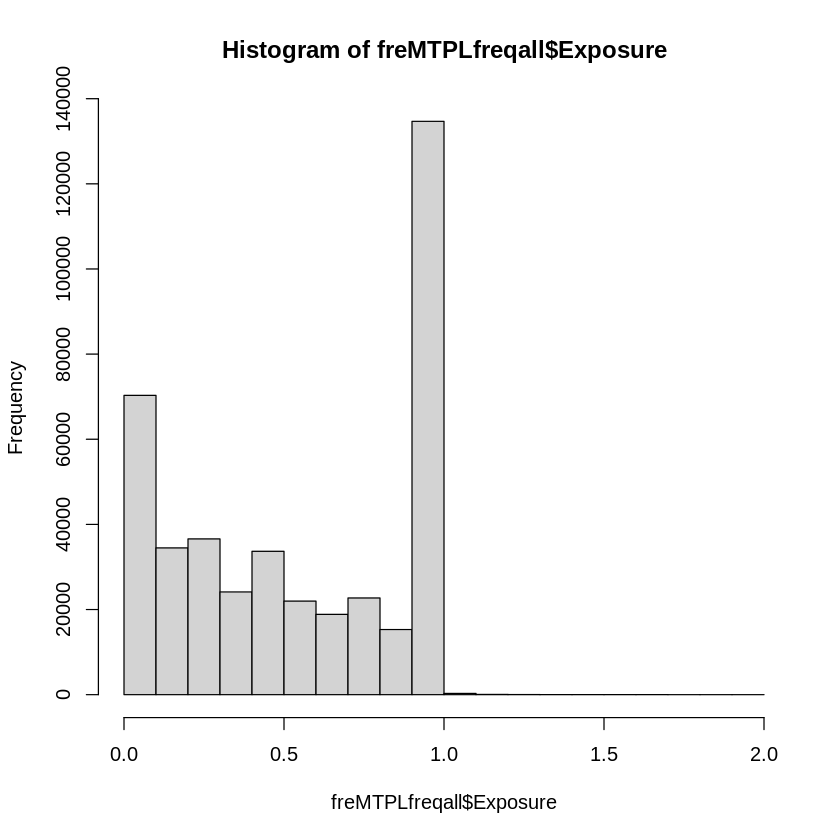

In [15]:

## -----------------------------------------------------------------------------------------------------
hist(freMTPLfreqall$Exposure)
sum(freMTPLfreqall$Exposure > 1)



Loại các Policy mà có exposure >1

In [16]:
summary(freMTPLfreqall[freMTPLfreqall$Exposure > 1, "ClaimNb"])
summary(freMTPLfreqall[freMTPLfreqall$Exposure <= 1, "ClaimNb"])
basefreq <- subset(freMTPLfreqall, Exposure <= 1)



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.04276 0.00000 2.00000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.03916 0.00000 4.00000 

In [17]:
summary(freMTPLsevall[freMTPLsevall$Exposure > 1, "ClaimAmount"])
summary(freMTPLsevall[freMTPLsevall$Exposure <= 1, "ClaimAmount"])
basecout <- subset(freMTPLsevall, Exposure <= 1)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   72.0   504.5  1040.5  1702.2  1569.0  7126.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      2     700    1156    2130    1243 2036833 

In [18]:
zero_exposure_data <- subset(freMTPLfreqall, Exposure == 0)
head(zero_exposure_data)

PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,TotalClaim
<fct>,<int>,<dbl>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<int>,<dbl>


13 thang 1.1
thang 4 2025 den t4 2026 thi trong 2025 exposure 7 thang => 7/12
exposure : the period of exposure of a policy in year

### CarAge Processing

[1]  80  81  82  83  83  84  85  99  99  99  99  99  99  99  99  99  99  99  99
[20]  99  99  99  99  99  99  99  99  99 100 100 100 100 100 100 100 100 100 100
[39] 100 100 100 100 100 100 100 100 100 100 100 100

[1] 43

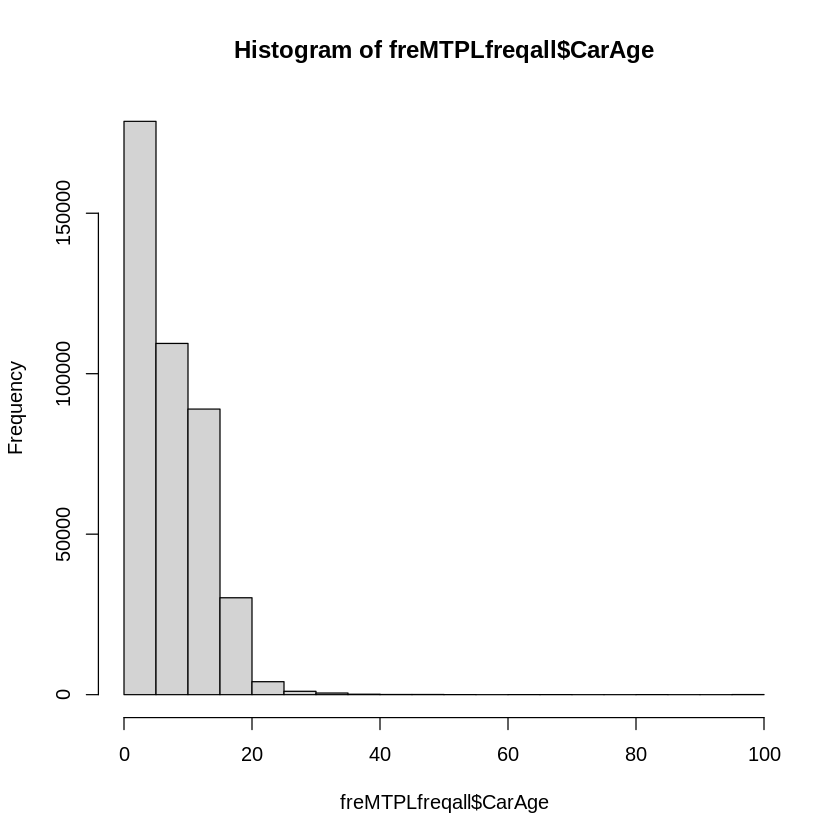

In [19]:
## -----------------------------------------------------------------------------------------------------
hist(freMTPLfreqall$CarAge)
tail(sort(freMTPLfreqall$CarAge), 50)
sum(freMTPLfreqall$CarAge > 98)

In [20]:

summary(freMTPLfreqall[freMTPLfreqall$CarAge > 98, "ClaimNb"])
summary(freMTPLfreqall[freMTPLfreqall$CarAge <= 98, "ClaimNb"])
basefreq <- subset(basefreq, CarAge <= 98)

summary(freMTPLsevall[freMTPLsevall$CarAge > 98, "ClaimAmount"])
summary(freMTPLsevall[freMTPLsevall$CarAge <= 98, "ClaimAmount"])
basecout <- subset(basecout, CarAge <= 98)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.02326 0.00000 1.00000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.03916 0.00000 4.00000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1110    1110    1110    1110    1110    1110 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
      2.0     697.5    1156.0    2130.0    1243.0 2036833.0 

### Exploratory Analysis of Claim Severity

In [21]:
## -----------------------------------------------------------------------------------------------------
amountvsnb <- function(x, add=FALSE, horiz=FALSE, main, ...)
{
  n <- length(x)
  if(missing(main))
    main <- "aggregate amount vs. claim number"
  if(!add)
  {
    z <- cumsum(sort(x))/sum(x)
    y <- (1:n)/n
    plot(z, y, type="l", ylim=0:1,
         ylab="% claim nb.", xlab="% agg. claim amount",
         main=main, ...)
    if(horiz)
      abline(h=1:10/10, lty=3, col="grey")
    else
      for(i in 3:19)
      {
        p <- i/20
        ind <- head(which(abs(y - p) < 1e-3), 1)
        lines(c(-1, z[ind]), c(p, p), lty=2, col="grey25")
        lines(c(z[ind], z[ind]), c(-1, p), lty=2, col="grey25")
        print(c(p, z[ind]))
      }
  }else
    lines(cumsum(sort(x))/sum(x), (1:n)/n, ...)

}

Plot distribution empirique

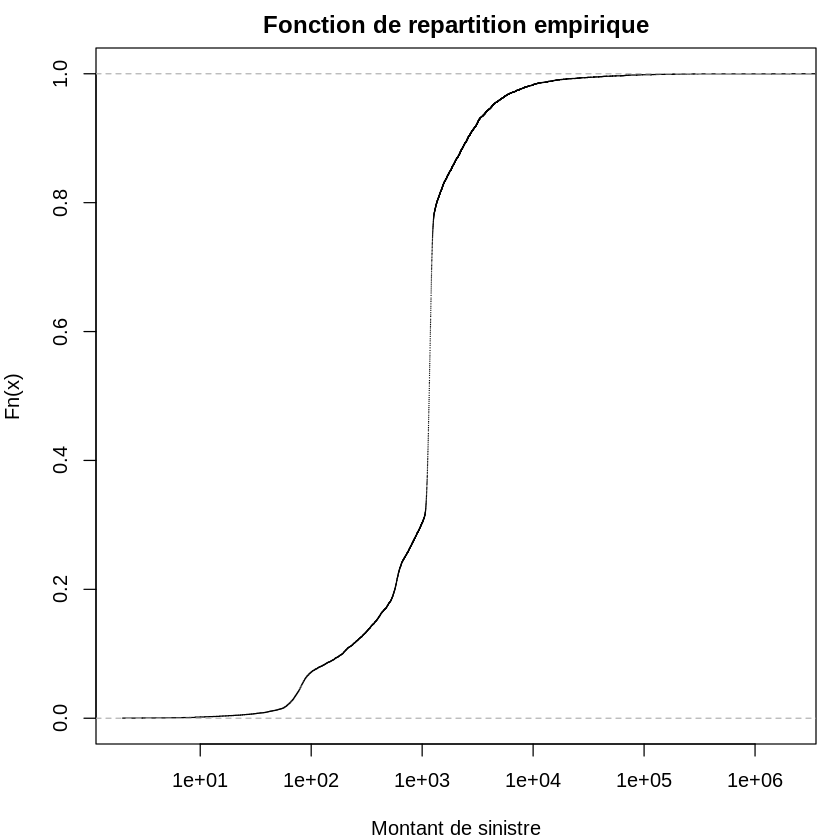

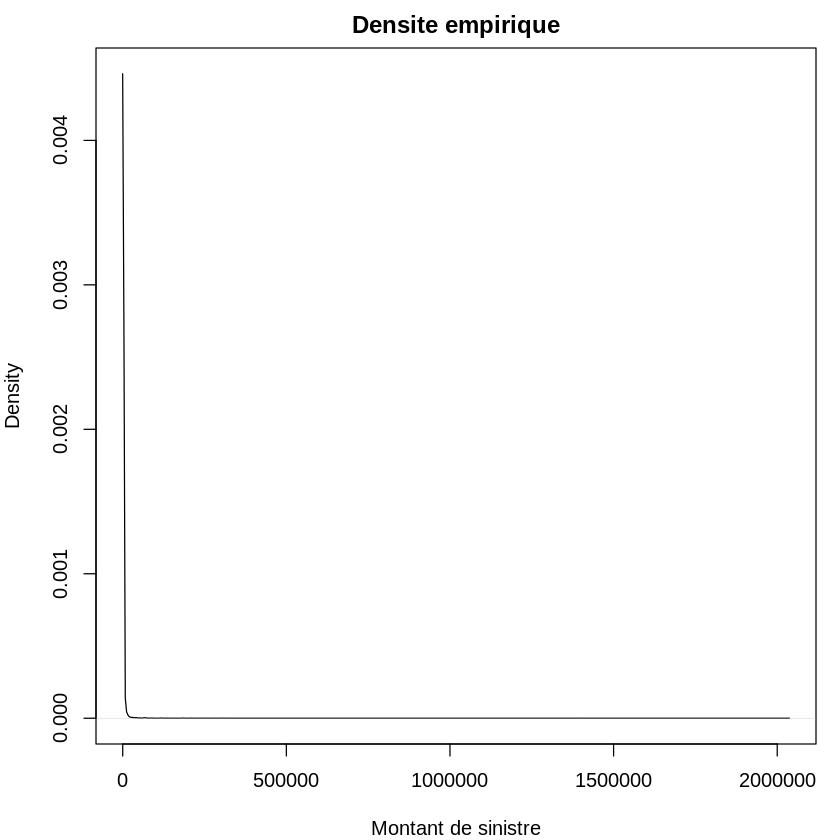

[1] 0.15000000 0.01054528
[1] 0.20000000 0.02178665
[1] 0.25000000 0.03623812
[1] 0.3000000 0.0557455
[1] 0.35000000 0.08066929
[1] 0.4000000 0.1067229
[1] 0.4500000 0.1332622
[1] 0.500000 0.160196
[1] 0.5500000 0.1874923
[1] 0.6000000 0.2151764
[1] 0.6500000 0.2431867
[1] 0.7000000 0.2715629
[1] 0.7500000 0.3004051
[1] 0.8000000 0.3303481
[1] 0.8500000 0.3663879
[1] 0.9000000 0.4168274
[1] 0.9500000 0.4926259


[1]  120931  125705  128791  132502  137003  152135  181697  182467  182568
[10]  186612  205090  209462  210837  240884  254944  281403  301302  306559
[19] 1402330 2036833

99%      99.1%      99.2%      99.3%      99.4%      99.5%      99.6% 
  16118.33   17497.65   20035.82   24760.04   29153.64   35431.97   43837.92 
     99.7%      99.8%      99.9%       100% 
  63116.91   73269.85  131904.53 2036833.00

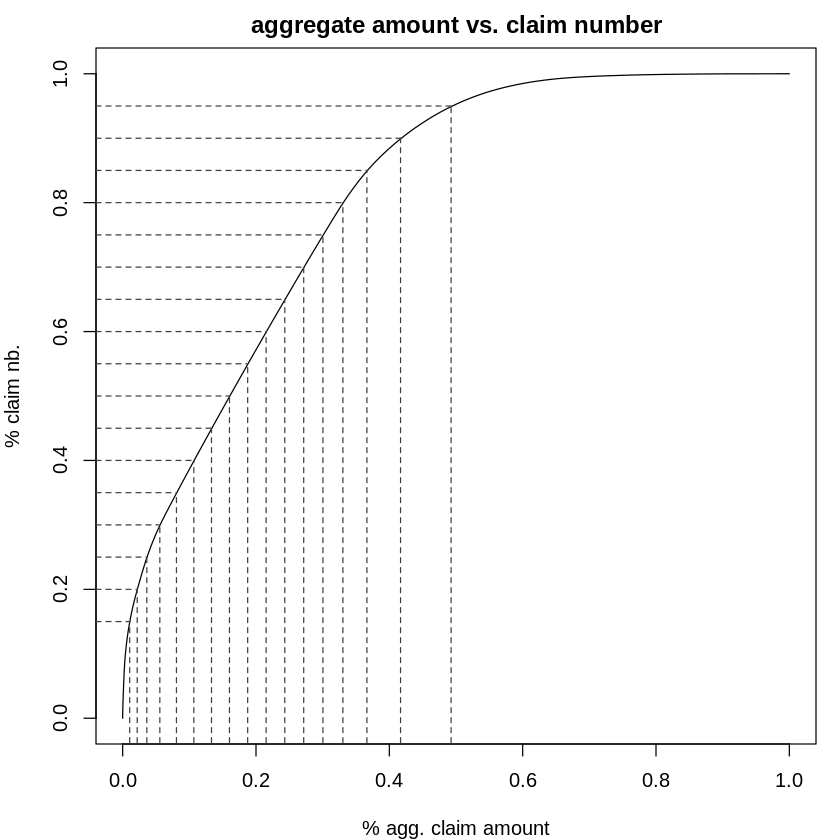

In [22]:
## -----------------------------------------------------------------------------------------------------
par(mar=c(4,4,2,1))
plot(ecdf(basecout$ClaimAmount), log="x", xlim=range(basecout$ClaimAmount), xlab="Montant de sinistre", main="Fonction de repartition empirique")
plot(density(basecout$ClaimAmount), xlab="Montant de sinistre", main="Densite empirique")
amountvsnb(basecout$ClaimAmount)
tail(sort(basecout$ClaimAmount), 20)
quantile(basecout$ClaimAmount, probs = seq(0.99, 1, by=0.001))


Phân bố claim severity có đuôi rất dày (heavy‑tailed)

right‑skewness

Valeurs extreme queue : pareto distribution GPD generalised pareto distribution

In [23]:
## ---- eval=FALSE--------------------------------------------------------------------------------------
## library(evir)
## ## Mean Excess Plot: si la tendance devient lineaire a partir d'un certain seuil, cela signifie que les grandes valeurs suivent une GPD (semble etre le cas ici, mais ce n'est pas evident).
## evir::meplot(basecout$ClaimAmount)
## ## Ou estimation par max. de vraisemblance indice de queue: reperer la stabilite de l'estimation du param. de la GPD en fonction du seuil (param doit devenir constant au-dessus du seuil).
## shape(basecout$ClaimAmount, models=30, start=30, end=600, reverse=TRUE, ci=0.95, auto.scale=TRUE, labels=TRUE)
## ## ou alors on peut utiliser le Hill plot:
## hill(basecout$ClaimAmount)
## ## Ou bien le mean residual life plot: + ou - la meme idee que le mean excess plot, au-dessus du seuil le graphique doit etre lineaire...signifie que GPD devient valide au-dessus du seuil.
## require(evd)
## mrlplot(basecout$ClaimAmount)	# difficile de tirer une conclusion!
##


## -----------------------------------------------------------------------------------------------------
(thres <- quantile(basecout$ClaimAmount, probs = 0.995))
basecoutattri <- subset(basecout, ClaimAmount <= thres)
basecoutatyp <- subset(basecout, ClaimAmount > thres)
sum(basecoutattri$ClaimAmount)
sum(basecoutatyp$ClaimAmount)
(prime.cat <- sum(basecoutatyp$ClaimAmount) / nrow(basefreq))


## -----------------------------------------------------------------------------------------------------
summary(freMTPLfreqall)
sapply(freMTPLfreqall, class)

99.5% 
35431.97

[1] 23649001

[1] 10784326

[1] 26.13083

    PolicyID         ClaimNb           Exposure            Power      
 1      :     1   Min.   :0.00000   Min.   :0.002732   f      :95718  
 2      :     1   1st Qu.:0.00000   1st Qu.:0.200000   g      :91198  
 3      :     1   Median :0.00000   Median :0.540000   e      :77022  
 4      :     1   Mean   :0.03916   Mean   :0.561088   d      :68014  
 5      :     1   3rd Qu.:0.00000   3rd Qu.:1.000000   h      :26698  
 6      :     1   Max.   :4.00000   Max.   :1.990000   j      :18038  
 (Other):413163                                        (Other):36481  
     CarAge          DriverAge                                    Brand       
 Min.   :  0.000   Min.   :18.00   Fiat                              : 16723  
 1st Qu.:  3.000   1st Qu.:34.00   Japanese (except Nissan) or Korean: 79060  
 Median :  7.000   Median :44.00   Mercedes, Chrysler or BMW         : 19280  
 Mean   :  7.532   Mean   :45.32   Opel, General Motors or Ford      : 37402  
 3rd Qu.: 12.000   3rd Qu.:54.00   ot

PolicyID    ClaimNb   Exposure      Power     CarAge  DriverAge      Brand 
  "factor"  "integer"  "numeric"   "factor"  "integer"  "integer"   "factor" 
       Gas     Region    Density TotalClaim 
  "factor"   "factor"  "integer"  "numeric"

In [24]:

## -----------------------------------------------------------------------------------------------------
## La fonction qui suit permet de calculer la moyenne et la variance de la reponse (par modalite et pour tout type de covariable), et en faire un graphique. Les arguments sont les suivants:
##    * 'facteur.risque' est le nom dans la base de donnees de la covariable a l'etude,
##    * 'expo' est le nom dans la base de donnees de la variable qui donne l'exposition au risque de chaque individu,
##    * 'reponse' est le nom dans la base de donnees de la variable reponse,
##    * 'basenb' est le nom de la base de donnees,
##    * 'texte' est le nom du graphique realise,
##    * 'niveau' designe les bornes des classes a creer pour une covariable continue,
##    * 'continu' est le type pour la covariable etudiee (quantitatif ou qualitatif).

graphSinistre <- function(facteur.risque, expo, reponse, basenb, texte = "Probabilite empirique annualisÃ©e d'etre sinistre", niveau, continu = TRUE)
{
  if (continu == TRUE) { X <- cut(basenb[ ,facteur.risque], niveau, include.lowest = TRUE) }
  if (continu == FALSE) { X <- as.factor(basenb[ ,facteur.risque]) }
  E <- basenb[ ,expo]
  Y <- basenb[ ,reponse]
  FREQ <- levels(X)
  moyenne <- variance <- n <- rep(NA, length(FREQ))
  for (k in 1:length(FREQ))
  {
    moyenne[k] <- mean( Y[X == FREQ[k]] , na.rm = TRUE)
    variance[k] <- var( Y[X == FREQ[k]] , na.rm = TRUE)
    n[k] <- sum(E[X == FREQ[k]], na.rm = TRUE)
  }
  w <- barplot(n, names.arg = FREQ, col = "light green", axes = FALSE,
               xlim = c(0,1.2*length(FREQ)+.5))
  mid <- w[ ,1]
  axis(2, col="light green") ; par(new = TRUE)
  IC1 <- moyenne + 1.96 / sqrt(n) * sqrt(variance)
  IC2 <- pmax(moyenne - 1.96 / sqrt(n) * sqrt(variance), 0)
  moyenneglobale <- mean(Y)
  plot(mid, moyenne, ylim = range(c(IC1,IC2)), type = "b", col = "red",
       axes = FALSE, xlab = facteur.risque, ylab = "", xlim = c(0,1.2*length(FREQ)+.5))
  segments(mid, IC1, mid, IC2, col = "red")
  segments(mid-.1, IC1, mid+.1, IC1, col = "red")
  segments(mid-.1, IC2, mid+.1, IC2, col = "red")

  points(mid, moyenne, pch = 19, col = "red")
  axis(4, col="red") ; abline(h = moyenneglobale, lty = 2, col = "red")
  mtext("Exposition", 2, line = 2, cex = 1.2, col = "light green")
  mtext(texte, 4, line = -2, cex = 1.2, col = "red")
}

visualize the relationship between a risk factor (covariate), an exposure variable, and a response variable

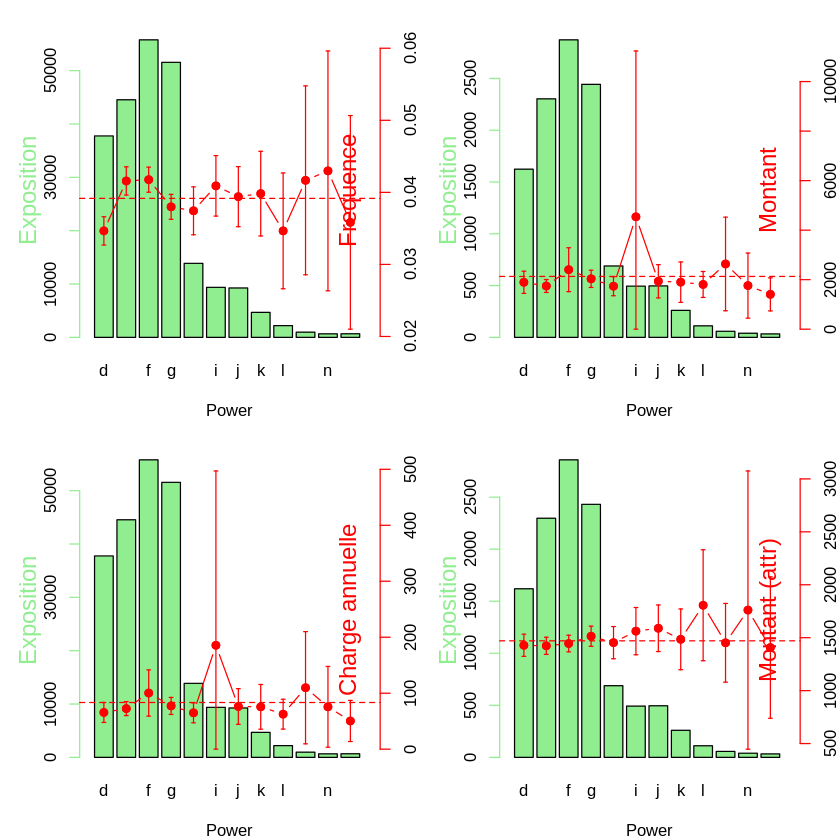

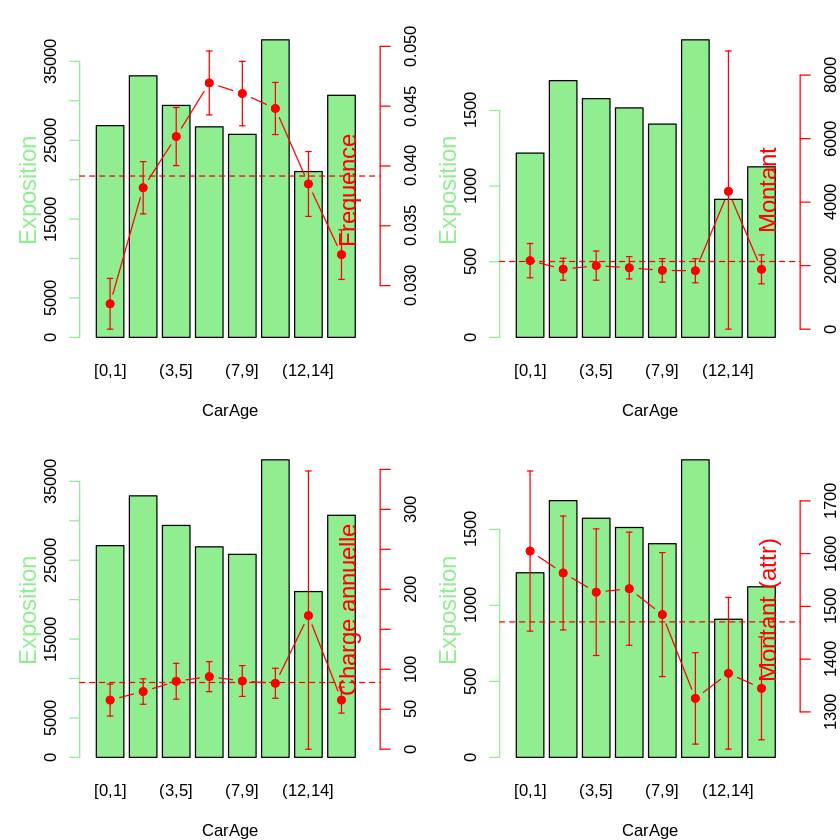

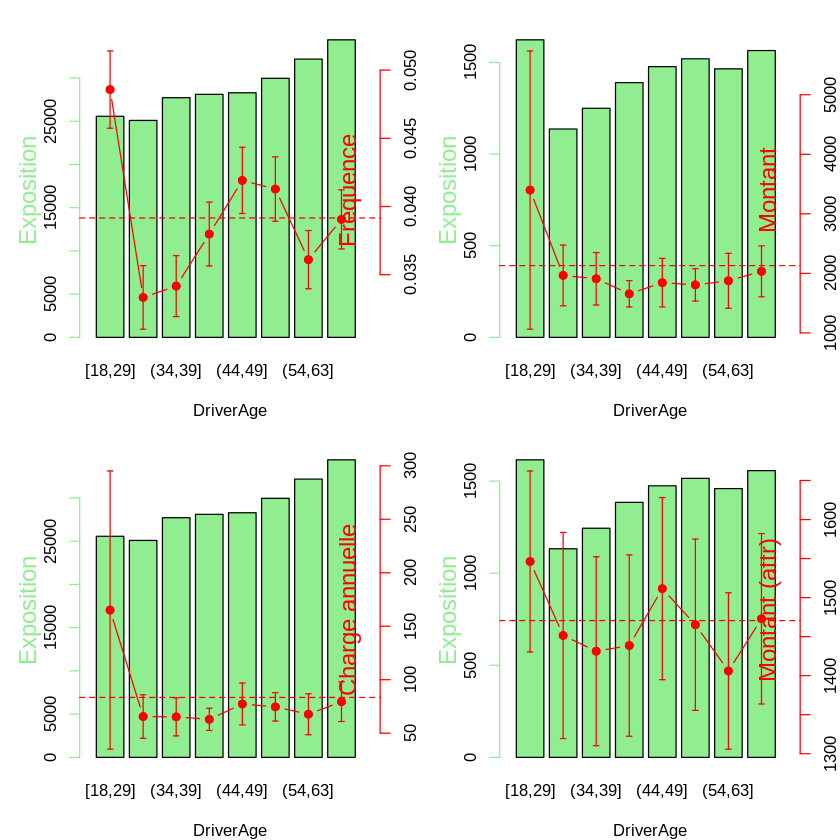

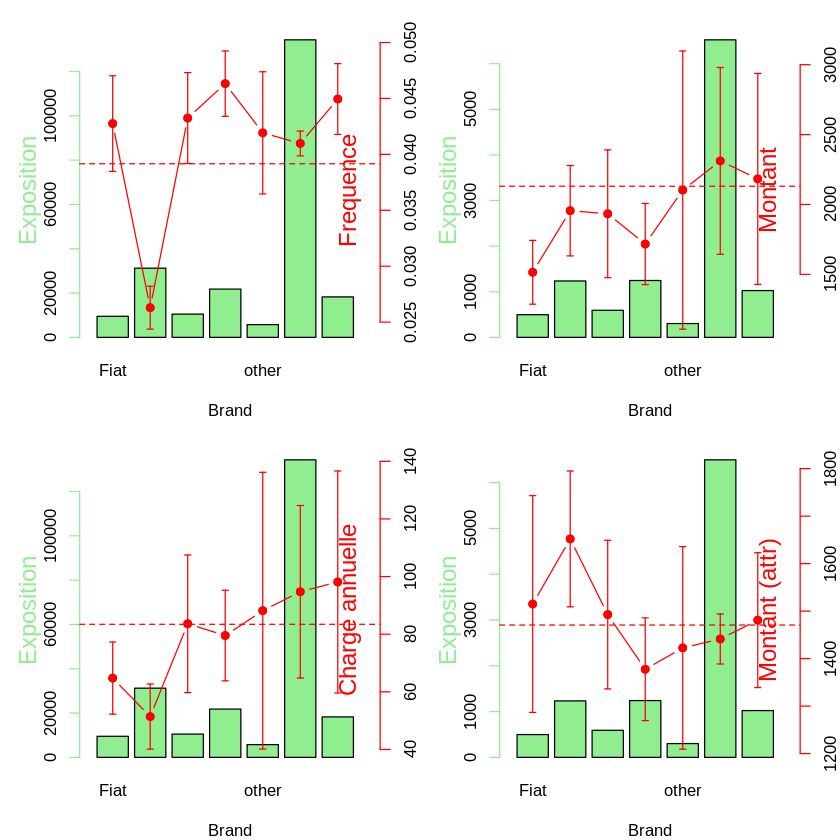

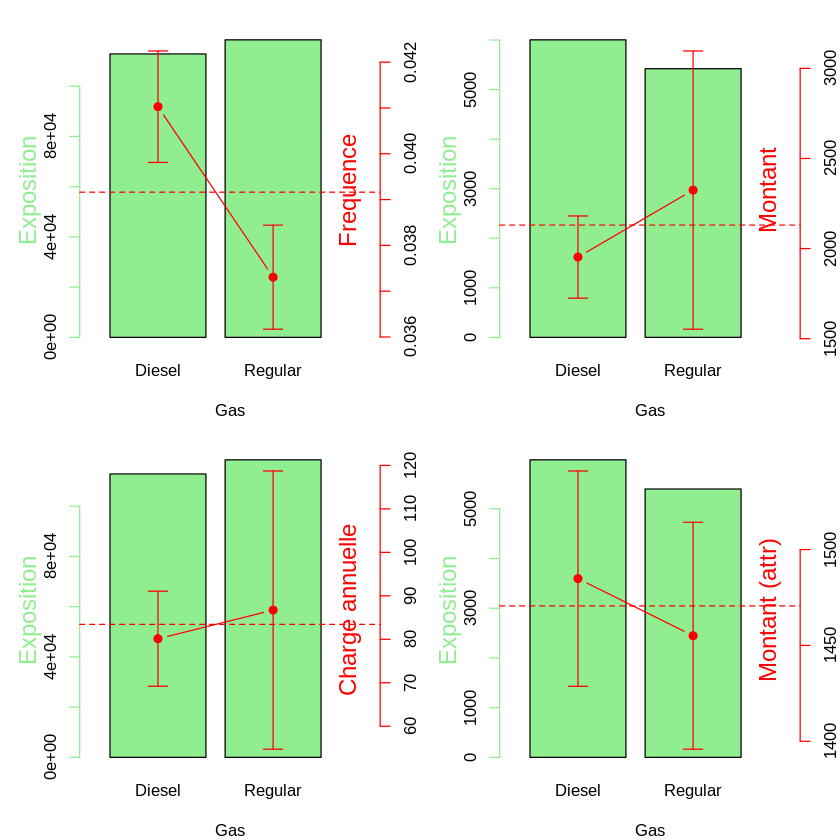

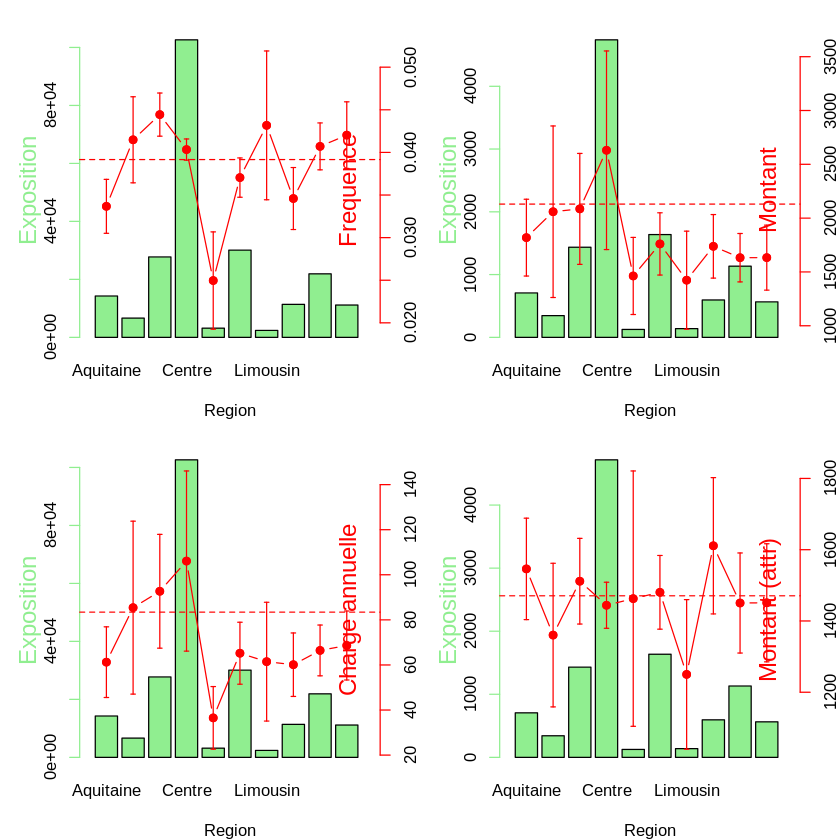

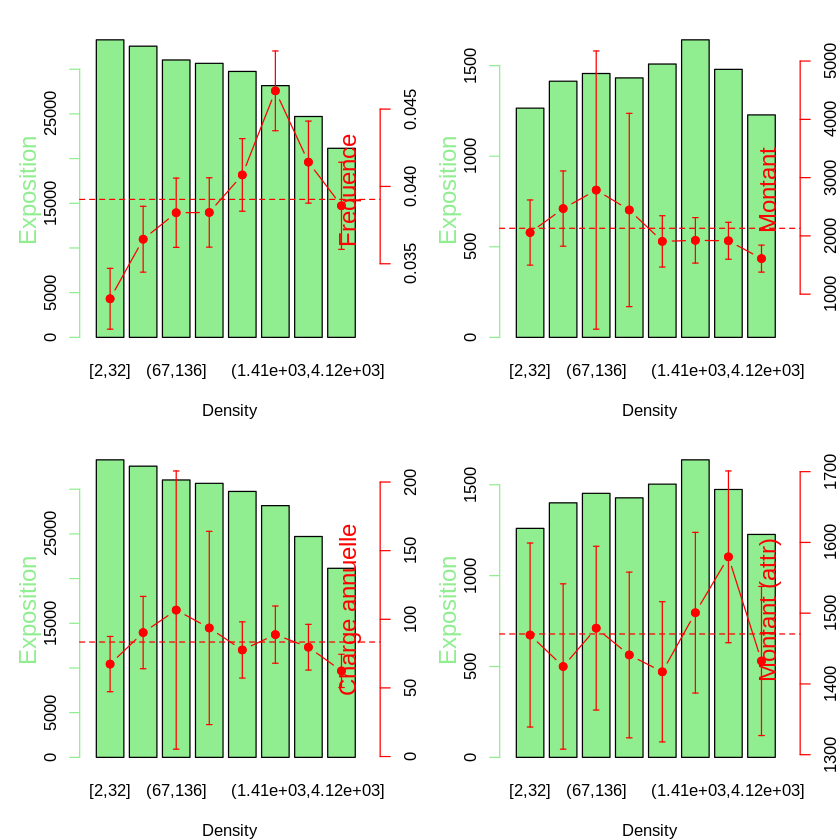

In [25]:

## -----------------------------------------------------------------------------------------------------
par(mar=c(4,4,2,2))
varlist <- c("Power", "CarAge", "DriverAge", "Brand", "Gas", "Region", "Density")

for(v in varlist)
{
  if(is.factor(basefreq[, v]))
  {
    iscontinu <- FALSE
    niveau <- NULL
  }else
  {
    iscontinu <- TRUE
    niveau <- quantile(basefreq[, v], probs=seq(0, 1, length=9))
  }
  par(mfrow=c(2,2))
  graphSinistre(v, "Exposure", "ClaimNb", basefreq, "Frequence",
                continu= iscontinu, niveau)
  graphSinistre(v, "Exposure", "ClaimAmount", basecout, "Montant",
                continu= iscontinu, niveau)
  graphSinistre(v, "Exposure", "TotalClaim", basefreq, "Charge annuelle",
                continu= iscontinu, niveau)
  graphSinistre(v, "Exposure", "ClaimAmount", basecoutattri, "Montant (attr)",
                continu= iscontinu, niveau)

}




Image 1 — Power

- Fréquence: Power d có fréquence cao nhất $(~0.042)$, g và f quanh mức trung bình, các Power cao $(i, j, k, l, n)$ frequency thấp hơn nhưng interval rộng do exposition ít. Không có trend đơn điệu rõ ràng → Power không phải driver mạnh của fréquence.
- Montant brut: Power g có spike lớn với CI rất rộng → rõ ràng bị kéo bởi sinistres atypiques. Montant attritionnaire (bottom-right) phẳng hơn nhiều, gần như không có variation → sau khi loại outliers, Power không ảnh hưởng đến severity.
- Charge annuelle: Khá phẳng ngoại trừ g bị spike từ outlier.

⇒ Power có tác động yếu trên fréquence (Power d cao hơn một chút), gần như không có tác động lên severity attritionnaire. Candidate cho grouping mạnh hoặc loại khỏi severity model.


Image 2 — CarAge

- Fréquence: Xe mới [0,1] có fréquence thấp nhất $(~0.028)$, tăng dần đến $(3,5]$ rồi đạt đỉnh ở $(7,9] (~0.047)$, sau đó giảm mạnh ở xe cũ $(12,14] (~0.030)$. Có dạng hình chuông — xe trung niên $(3-11 tuổi)$ có frequency cao nhất.
- Montant brut: Khá ổn định ngoại trừ xe rất cũ $(12,14]$ có spike (CI rộng, ít observations). Montant attritionnaire (bottom-right) cho thấy xu hướng giảm nhẹ theo tuổi xe — xe cũ hơn → sinistres nhỏ hơn (có thể do xe cũ được bảo hiểm với valeur thấp hơn).
- Charge annuelle: Phản ánh frequency — đỉnh ở CarAge trung bình.

⇒ CarAge ảnh hưởng rõ lên fréquence (hình chuông). Trên severity, ảnh hưởng yếu hơn. Grouping hợp lý: $[0,3], (3,11], (11,+∞)$ — nhưng cần cân nhắc tách $(3,11]$ thêm nếu muốn bắt được đỉnh.


Image 3 — DriverAge
- Fréquence: Rất rõ ràng — lái xe trẻ $[18,29]$ có fréquence cao nhất (~0.050), sau đó giảm mạnh ở $[34,39] (~0.032)$, rồi tăng nhẹ trở lại ở tuổi trung niên $~0.041 ([44,49])$, rồi giảm dần ở người lớn tuổi. Đây là pattern U-shape không hoàn chỉnh: trẻ rủi ro cao, trung niên ổn định, già giảm nhẹ.
- Montant brut: $[18,29]$ có CI rất rộng → volatilité cao, ít sinistres nhưng khi xảy ra thì lớn. Montant attritionnaire phẳng hơn nhiều — severity attritionnaire khá đồng đều qua các nhóm tuổi $(~1,400–1,600)$.
- Charge annuelle: Hoàn toàn dominated bởi fréquence — lái xe trẻ có charge cao nhất, giảm dần.

⇒ DriverAge là biến discriminante nhất về fréquence. Grouping $(-∞, 30], (30,45], (45,55], (55,65], (65,+∞)$ trong code là hợp lý và bắt được các inflection points.


Image 4 — Brand

- Fréquence: Nhãn xe "other" (Japanese/Korean) có fréquence cao nhất (~0.046), Fiat và các nhãn châu Âu thấp hơn $(~0.025–0.030)$. Variation đáng kể nhưng CI rộng ở nhãn nhỏ.
- Montant brut: "other" có spike lớn → bị kéo bởi outliers. Montant attritionnaire (bottom-right) cho thấy variation hạn chế hơn — các nhãn châu Âu (French, Italy Germany) có severity attritionnaire thấp hơn một chút so với Asian/Korean.
- Charge annuelle: Phản ánh kết hợp freq × montant, "other" (Japanese) dominant cả 2 chiều.

⇒ Brand có tín hiệu rõ trên fréquence. Severity attritionnaire ít biến động hơn. Grouping hiện tại thành Asian, French, Italy Germany, US là hợp lý. Lưu ý: nhóm "Fiat" có exposure nhỏ → có thể merge với một nhóm khác.


Image 5 — Gas
- Fréquence: Diesel $(~0.041)$ cao hơn rõ Regular $(~0.037)$ — difference khoảng 10%, có ý nghĩa thống kê (CI không overlap).
- Montant: Đảo chiều so với fréquence — Regular có montant brut và montant attritionnaire cao hơn Diesel một chút. Tuy nhiên CI overlap nhiều → difference on severity ít significant.
- Charge annuelle: Gần như bằng nhau giữa Diesel và Regular sau khi tính cả 2 chiều.

⇒  Gas có tín hiệu nhất định trên fréquence (Diesel rủi ro hơn), nhưng tác động trên severity rất yếu. Trong Gamma model, Gas thường không significant — candidate cho loại khỏi severity model, giữ trong frequency model.


Image 6 — Region
- Fréquence: Variation lớn — Centre và một số régions phía Bắc (NPDC) có fréquence cao $(~0.045–0.048)$, Bretagne và Limousin thấp hơn $(~0.020–0.025)$. CI rộng ở các régions nhỏ.
- Montant brut: Centre có spike lớn → outliers. Montant attritionnaire khá phẳng (~1,300–1,600), variation vừa phải.
- Charge annuelle: Driven bởi fréquence — Centre dominates.

⇒ Region có tín hiệu rõ trên fréquence. Grouping đã làm $(IDF, C-B, PC-NPDC-AQUIT, PDL-BN-HN-LIM)$ là hợp lý về mặt geographic và statistical. Trên severity, tác động yếu hơn.


Image 7 — Density
- Fréquence: Tăng đơn điệu theo density — rural $[2,32]$ thấp nhất $(~0.036)$, urban cao $(1,410–4,120]$ cao hơn $(~0.044)$. Trend đơn điệu và rõ ràng.
- Montant brut: Density thấp (rural) có montant cao hơn $(~2,500–3,000)$, giảm dần khi density tăng. Điều này hợp lý: tai nạn ở vùng thưa dân thường nghiêm trọng hơn (tốc độ cao, đường vắng).
- Montant attritionnaire (bottom-right): Trend ngược chiều nhẹ — rural severity cao hơn urban một chút, nhưng variation nhỏ.

⇒ Density là biến tốt — tín hiệu rõ cả trên fréquence lẫn severity (hai chiều ngược nhau, có thể bù trừ một phần trong charge). Grouping $(-∞,100], (100,500], (500,1000], (1000,5000], (5000,+∞)$ hiện tại khá granulaire — có thể giữ hoặc simplify tùy theo significance trong model.

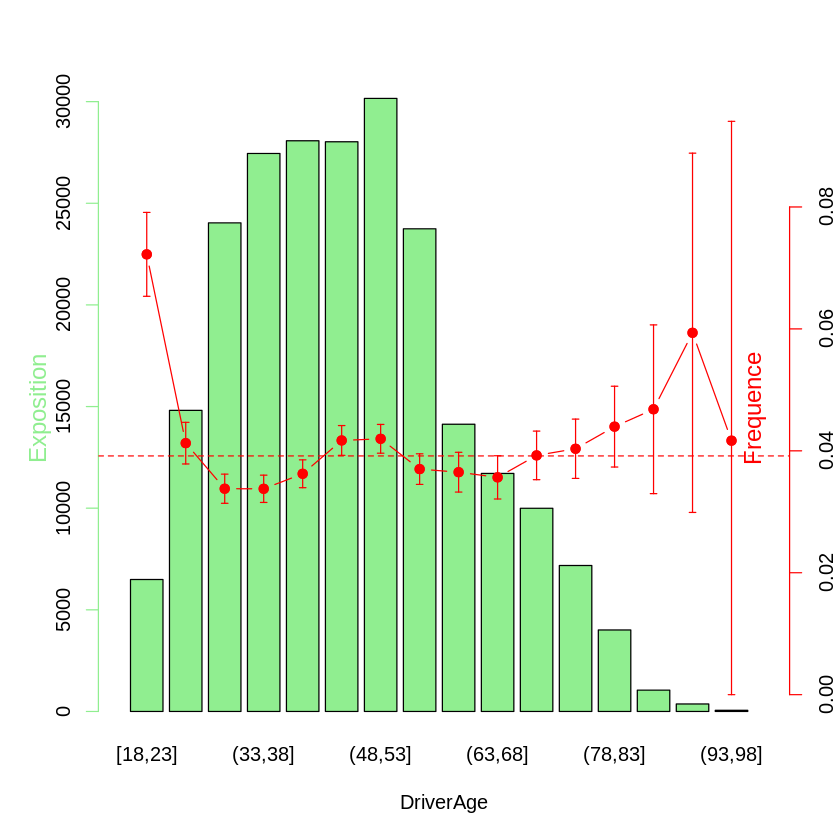

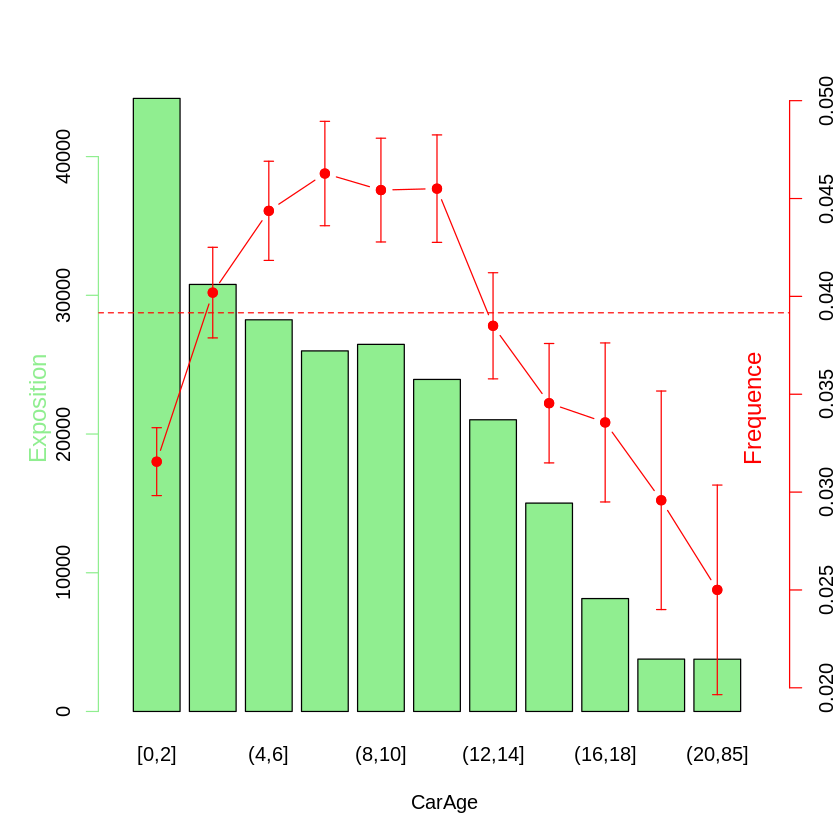

In [129]:
v <- "DriverAge"
niveauv <- seq(min(basefreq[, v]), max(basefreq[, v]), by=5)
graphSinistre(facteur.risque = v, expo = "Exposure", reponse = "ClaimNb",
              texte = "Frequence", basenb = basefreq, continu=TRUE, niveau=niveauv)

v <- "CarAge"
niveauv <- c(seq(min(basefreq[, v]), 20, by=2), max(basefreq[, v]))
graphSinistre(facteur.risque = v, expo = "Exposure", reponse = "ClaimNb",
              texte = "Frequence", basenb = basefreq, continu=TRUE, niveau=niveauv)

## 2.1 Grouping variable

In [132]:
# ## -----------------------------------------------------------------------------------------------------
# regrouprecode <- function(base, listvar, listlevel)
# {
#   for(i in 1:length(listvar))
#   {
#     if(is.factor(base[, listvar[i]]))
#       levels(base[, listvar[i]]) <- listlevel[[i]]
#     else
#     {
#       base[, listvar[i]] <- cut(base[, listvar[i]], listlevel[[i]])
#     }
#   }

#   base
# }
library(forcats)

regrouprecode <- function(base, listvar, listlevel)
{
  for(i in 1:length(listvar))
  {
    if(is.factor(base[, listvar[i]]))
    {
      # Tạo named mapping: tên cũ → tên mới
      mapping <- listlevel[[i]]
      names(mapping) <- levels(base[, listvar[i]])
      # Đảo ngược: tên mới → vector các tên cũ (format fct_collapse cần)
      groups <- split(names(mapping), mapping)
      base[, listvar[i]] <- fct_collapse(base[, listvar[i]], !!!groups)
    }
    else
    {
      base[, listvar[i]] <- cut(base[, listvar[i]], listlevel[[i]])
    }
  }
  base
}

### Power Grouping

group Power -> newPower

không làm như cô vì ta thấy e f không significant

In [134]:

# newPower <- c("d", "e", "f", "g-h", "g-h", "i-j-k", "i-j-k",
#               "i-j-k", "l-o", "m-n", "m-n", "l-o")
# Và cập nhật newPower để merge e-f
newPower <- c("d", "e-f", "e-f", "g-h", "g-h", "i-j-k", "i-j-k",
              "i-j-k", "l-o", "l-o", "l-o", "l-o")
cbind(levels(basecout$Power), newPower)



,newPower
d,d
e,e-f
f,e-f
g,g-h
h,g-h
i,i-j-k
j,i-j-k
k,i-j-k
l,l-o
m,l-o


essai = bien tam thoi cua dataframe  

Trong đoạn mã R, basecout là một tập dữ liệu con được tạo ra từ freMTPLsevall. Cụ thể, nó chứa tất cả các dòng từ freMTPLsevall mà giá trị của cột Exposure (mức độ phơi nhiễm/thời gian bảo hiểm) nhỏ hơn hoặc bằng 1.

In [ ]:
#un exemple
essai=basecout
levels(essai$Power)
levels(essai$Power)=newPower
levels(essai$Power)
essai$Power

### Region Grouping

Bretagne được giữ riêng thành 1 group — nhưng từ model output:
RegionBretagne : 0.0019   p = 0.95   ← hoàn toàn không significant
Coefficient gần bằng 0, p-value = 0.95 → Bretagne không khác gì reference group, không cần giữ riêng.

Đề xuất: Merge Bretagne vào Centre hoặc PDL-BN-HN-LIM — hai nhóm địa lý gần nhất về mặt fréquence từ plot Image 6.
Vấn đề kỹ thuật: Tương tự Power, levels<- vẫn không thực sự merge. Cần fct_collapse.

#### Bơ tít test

In [135]:
# Trên data GỐC (trước khi group) — basefreq
region_stats <- aggregate(
  cbind(ClaimNb, Exposure) ~ Region,
  data = basefreq,
  FUN  = sum
)
region_stats$freq_empirique <- region_stats$ClaimNb / region_stats$Exposure

# Thêm confidence interval (Wilson approximation)
region_stats$n_polices <- as.numeric(table(basefreq$Region))
region_stats$IC_lower  <- region_stats$freq_empirique -
                          1.96 * sqrt(region_stats$freq_empirique / region_stats$Exposure)
region_stats$IC_upper  <- region_stats$freq_empirique +
                          1.96 * sqrt(region_stats$freq_empirique / region_stats$Exposure)

# Trier theo fréquence
region_stats[order(region_stats$freq_empirique), ]

,Region,ClaimNb,Exposure,freq_empirique,n_polices,IC_lower,IC_upper
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,Centre,6474,102625.173,0.06308394,160517,0.06154724,0.06462064
3,Bretagne,1871,27738.984,0.06745020,42106,0.06439385,0.07050655
2,Basse-Normandie,451,6632.651,0.06799694,10873,0.06172131,0.07427257
5,Haute-Normandie,219,3164.882,0.06919689,8772,0.06003214,0.07836164
10,Poitou-Charentes,800,11152.009,0.07173596,19035,0.06676491,0.07670700
9,Pays-de-la-Loire,1576,21902.346,0.07195576,38717,0.06840319,0.07550834
1,Aquitaine,1053,14260.677,0.07383941,31272,0.06937946,0.07829936
7,Limousin,197,2392.745,0.08233223,4563,0.07083501,0.09382945
8,Nord-Pas-de-Calais,940,11382.684,0.08258158,27177,0.07730229,0.08786086


Bretagne [0.064, 0.071] và Centre [0.062, 0.065] — IC overlap hoàn toàn → không khác nhau có ý nghĩa thống kê
Basse-Normandie và Haute-Normandie có IC rất rộng do exposure nhỏ (10,873 và 8,772 polices)

In [136]:
# Model Poisson avec Region seule — không bị confound bởi các biến khác
pois_region <- glm(ClaimNb ~ Region + offset(log(Exposure)),
                   family = poisson("log"),
                   data   = basefreq)
summary(pois_region)

# Coefficients + p-values cho từng région vs reference (Aquitaine)
round(coef(summary(pois_region)), 4)


Call:
glm(formula = ClaimNb ~ Region + offset(log(Exposure)), family = poisson("log"), 
    data = basefreq)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -2.60586    0.03082 -84.562  < 2e-16 ***
RegionBasse-Normandie    -0.08243    0.05628  -1.465   0.1430    
RegionBretagne           -0.09050    0.03852  -2.349   0.0188 *  
RegionCentre             -0.15743    0.03323  -4.738 2.16e-06 ***
RegionHaute-Normandie    -0.06494    0.07426  -0.874   0.3819    
RegionIle-de-France       0.15008    0.03657   4.105 4.05e-05 ***
RegionLimousin            0.10887    0.07763   1.403   0.1608    
RegionNord-Pas-de-Calais  0.11189    0.04487   2.494   0.0126 *  
RegionPays-de-la-Loire   -0.02584    0.03980  -0.649   0.5162    
RegionPoitou-Charentes   -0.02890    0.04690  -0.616   0.5377    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 10548

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-2.6059,0.0308,-84.5625,0.0000
RegionBasse-Normandie,-0.0824,0.0563,-1.4648,0.1430
RegionBretagne,-0.0905,0.0385,-2.3493,0.0188
RegionCentre,-0.1574,0.0332,-4.7378,0.0000
RegionHaute-Normandie,-0.0649,0.0743,-0.8744,0.3819
RegionIle-de-France,0.1501,0.0366,4.1045,0.0000
RegionLimousin,0.1089,0.0776,1.4025,0.1608
RegionNord-Pas-de-Calais,0.1119,0.0449,2.4937,0.0126
RegionPays-de-la-Loire,-0.0258,0.0398,-0.6493,0.5162
RegionPoitou-Charentes,-0.0289,0.0469,-0.6162,0.5377


In [137]:
# Group 5 (tác giả — giữ Bretagne riêng)
basefreq$Region5 <- fct_collapse(basefreq$Region,
  "PC-NPDC-AQUIT" = c("Aquitaine", "Nord-Pas-de-Calais", "Poitou-Charentes"),
  "PDL-BN-HN-LIM" = c("Pays-de-la-Loire", "Basse-Normandie",
                       "Haute-Normandie", "Limousin"),
  "Bretagne"      = "Bretagne",
  "Centre"        = "Centre",
  "IDF"           = "Ile-de-France"
)

# Group 4 (merge Bretagne vào PDL-BN-HN-LIM)
basefreq$Region4 <- fct_collapse(basefreq$Region,
  "PC-NPDC-AQUIT"    = c("Aquitaine", "Nord-Pas-de-Calais", "Poitou-Charentes"),
  "PDL-BN-HN-LIM-BN" = c("Pays-de-la-Loire", "Basse-Normandie",
                           "Haute-Normandie", "Limousin", "Bretagne"),
  "Centre"           = "Centre",
  "IDF"              = "Ile-de-France"
)

# Fit 2 models
pois_r5 <- glm(ClaimNb ~ Region5 + offset(log(Exposure)),
               family = poisson("log"), data = basefreq)
pois_r4 <- glm(ClaimNb ~ Region4 + offset(log(Exposure)),
               family = poisson("log"), data = basefreq)

# So sánh AIC
cat("AIC 5 groups (Bretagne riêng):", AIC(pois_r5), "\n")
cat("AIC 4 groups (Bretagne merged):", AIC(pois_r4), "\n")

# Likelihood Ratio Test — test xem merge có làm mất thông tin không
anova(pois_r4, pois_r5, test = "Chisq")

AIC 5 groups (Bretagne riêng): 136517.4 
AIC 4 groups (Bretagne merged): 136519.3 


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,412701,105289.4,NA,NA,NA
2,412700,105285.5,1,3.889462,0.04858997


###

#### Group Region

In [138]:


# newRegion <- c("PC-NPDC-AQUIT","PDL-BN-HN-LIM","Bretagne","Centre",
#                "PDL-BN-HN-LIM","IDF","PDL-BN-HN-LIM","PC-NPDC-AQUIT",
#                "PDL-BN-HN-LIM","PC-NPDC-AQUIT")


newRegion <- c("AQUIT-PDL-PC-HN-LIM",  # 1. Aquitaine
               "AQUIT-PDL-PC-HN-LIM",  # 2. Basse-Normandie
               "Bretagne",              # 3. Bretagne — giữ riêng
               "Centre",               # 4. Centre — giữ riêng
               "AQUIT-PDL-PC-HN-LIM",  # 5. Haute-Normandie
               "IDF",                  # 6. Ile-de-France — giữ riêng
               "AQUIT-PDL-PC-HN-LIM",  # 7. Limousin
               "NPDC",                 # 8. Nord-Pas-de-Calais — TÁCH RIÊNG
               "AQUIT-PDL-PC-HN-LIM",  # 9. Pays-de-la-Loire
               "AQUIT-PDL-PC-HN-LIM")  # 10. Poitou-Charentes

cbind(levels(basecout$Region), newRegion)



,newRegion
Aquitaine,AQUIT-PDL-PC-HN-LIM
Basse-Normandie,AQUIT-PDL-PC-HN-LIM
Bretagne,Bretagne
Centre,Centre
Haute-Normandie,AQUIT-PDL-PC-HN-LIM
Ile-de-France,IDF
Limousin,AQUIT-PDL-PC-HN-LIM
Nord-Pas-de-Calais,NPDC
Pays-de-la-Loire,AQUIT-PDL-PC-HN-LIM
Poitou-Charentes,AQUIT-PDL-PC-HN-LIM


### Brand Grouping

merge Brand

In [29]:
newBrand <- c("Italy Germany", "Asian", "Italy Germany",
              "US", "US",
              "French", "Italy Germany")
cbind(levels(basecout$Brand), newBrand)

,newBrand
Fiat,Italy Germany
Japanese (except Nissan) or Korean,Asian
"Mercedes, Chrysler or BMW",Italy Germany
"Opel, General Motors or Ford",US
other,US
"Renault, Nissan or Citroen",French
"Volkswagen, Audi, Skoda or Seat",Italy Germany


### DriveAge, CarAge, Density Grouping

In [30]:


# Crée un vecteur qui définit des intervalles d'âge pour les conducteurs
newDrivAge <- c(-Inf, 30, 45, 55, 65, Inf)
newCarAge <- c(-Inf, 3, 5, 9, 11, Inf)
newDensity <- c(0, 100, 500, 1000, 5000, Inf)



basecoutattri est le dataframe d'entrée contenant des informations sur les sinistres et les attributs des polices d'assurance  


Le résultat de cette transformation (le dataframe avec les variables recodées/discrétisées) est stocké dans un nouveau dataframe appelé basecoutattri2

### Group

In [31]:
basecoutattri2 <- regrouprecode(basecoutattri, c("Power", "Region", "Brand", "DriverAge",
                                                 "CarAge", "Density"),
                                list(newPower, newRegion, newBrand, newDrivAge, newCarAge,
                                     newDensity))

summary(basecoutattri2)


    PolicyID       ClaimAmount       ClaimNb         Exposure      
 Min.   :    33   Min.   :    2   Min.   :1.000   Min.   :0.00274  
 1st Qu.: 83947   1st Qu.:  692   1st Qu.:1.000   1st Qu.:0.46000  
 Median :169959   Median : 1155   Median :1.000   Median :0.80000  
 Mean   :185119   Mean   : 1471   Mean   :1.102   Mean   :0.70788  
 3rd Qu.:281732   3rd Qu.: 1240   3rd Qu.:1.000   3rd Qu.:1.00000  
 Max.   :412944   Max.   :35431   Max.   :4.000   Max.   :1.00000  
                                                                   
   Power            CarAge         DriverAge              Brand     
 d    :2347   (-Inf,3] :4242   (-Inf,30]:3092   Italy Germany:2997  
 e    :3186   (3,5]    :2096   (30,45]  :5459   Asian        :2070  
 f    :3967   (5,9]    :3945   (45,55]  :4002   US           :2132  
 g-h  :4434   (9,11]   :1934   (55,65]  :1889   French       :8882  
 i-j-k:1801   (11, Inf]:3864   (65, Inf]:1639                       
 l-o  : 216                               

In [32]:
basefreq2 <- regrouprecode(basefreq, c("Power", "Region", "Brand", "DriverAge",
                                       "CarAge", "Density"),
                           list(newPower, newRegion, newBrand, newDrivAge, newCarAge,
                                newDensity))

In [33]:
basecoutatyp2 <- regrouprecode(basecoutatyp,  c("Power", "Region", "Brand", "DriverAge",
                                                "CarAge", "Density"),
                               list(newPower, newRegion, newBrand, newDrivAge, newCarAge,
                                    newDensity))

corrplot 0.95 loaded



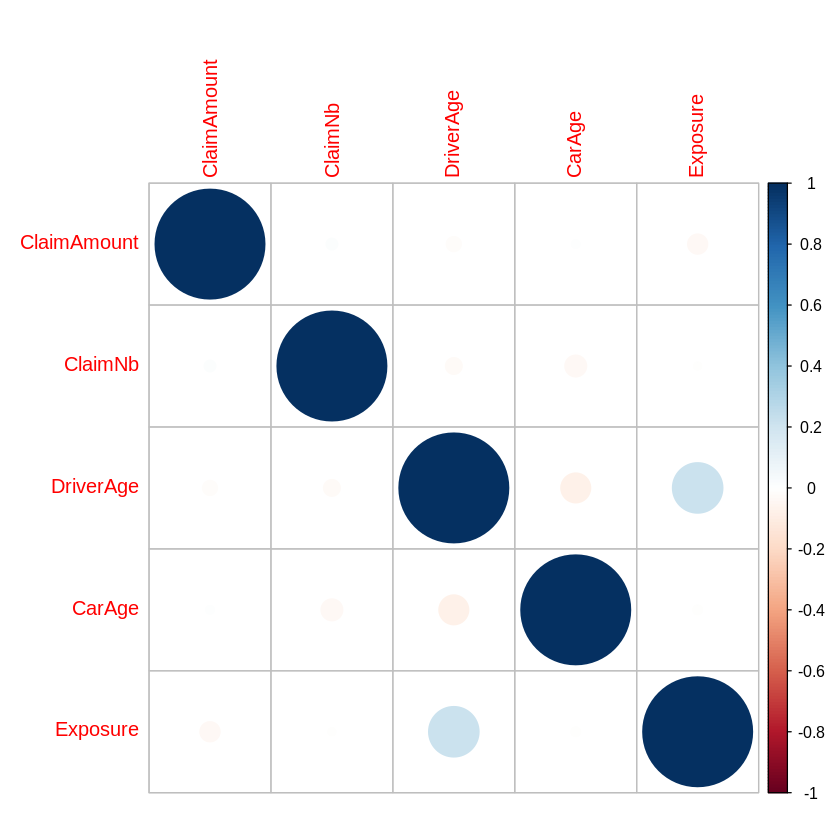

In [34]:
## -----------------------------------------------------------------------------------------------------
library(corrplot)
corrplot(cor(basecout[, c("ClaimAmount", "ClaimNb", "DriverAge", "CarAge", "Exposure")]))

In [35]:



#_____ Analyse des correlations entre facteurs de risque qualitatifs_____#
var.quali <- basecoutattri2[ ,varlist[varlist != "Exposure"]]
corr.quali <- matrix(NA, nrow = ncol(var.quali), ncol = ncol(var.quali))
for (i in 1:nrow(corr.quali)) {
  for (j in 1:ncol(corr.quali)) {
    ## On recupere la p-valeur du test d'independance du chi-2 de Pearson (ou le nb de degres de liberte = produit du (nb de modalites-1) pour chacune des 2 variables a l'etude) :
    ## une petite p-valeur conduit a rejeter l'hypothese d'independance entre les variables (H0).
    if(i < j)
      corr.quali[i,j] <- chisq.test(var.quali[ ,i], var.quali[ ,j])$p.value
    else
      corr.quali[i,j] <- chisq.test(var.quali[ ,i], var.quali[ ,j])$statistic
  }
}
rownames(corr.quali) <- colnames(corr.quali) <- varlist[varlist != "Exposure"]
corr.quali


Warning message in chisq.test(var.quali[, i], var.quali[, j]):
“Chi-squared approximation may be incorrect”


,Power,CarAge,DriverAge,Brand,Gas,Region,Density
Power,96486.0000,7.353886e-70,2.950159e-27,5.132034e-284,0.000000e+00,1.973386e-41,6.376920e-25
CarAge,400.0448,6.432400e+04,3.555511e-28,0.000000e+00,6.945984e-58,7.716506e-159,1.655819e-68
DriverAge,187.2869,1.718759e+02,6.432400e+04,1.702145e-45,2.118233e-35,2.006750e-17,2.317100e-20
Brand,1388.0919,2.498251e+03,2.447474e+02,4.824300e+04,4.473430e-15,0.000000e+00,1.735792e-252
Gas,1614.3194,2.730713e+02,1.685718e+02,6.990481e+01,1.607699e+04,1.530465e-36,1.333513e-73
Region,259.6822,7.949116e+02,1.170688e+02,2.261360e+03,1.738884e+02,6.432400e+04,0.000000e+00
Density,175.0689,3.681859e+02,1.322768e+02,1.213926e+03,3.459194e+02,8.648618e+03,6.432400e+04


In [36]:
 var.quanti <- basecoutattri2[ ,c("ClaimAmount", "ClaimNb")]			# on ne met pas l'exposition car ce n'est pas une covariable a proprement parler
(corr.quanti.lineaire <- cor(var.quanti, method = c("pearson")))
(corr.quanti.lineaire <- cor(var.quanti, method = c("kendall")))

,ClaimAmount,ClaimNb
ClaimAmount,1.00000000,0.01834306
ClaimNb,0.01834306,1.00000000


,ClaimAmount,ClaimNb
ClaimAmount,1.000000e+00,9.179623e-05
ClaimNb,9.179623e-05,1.000000e+00


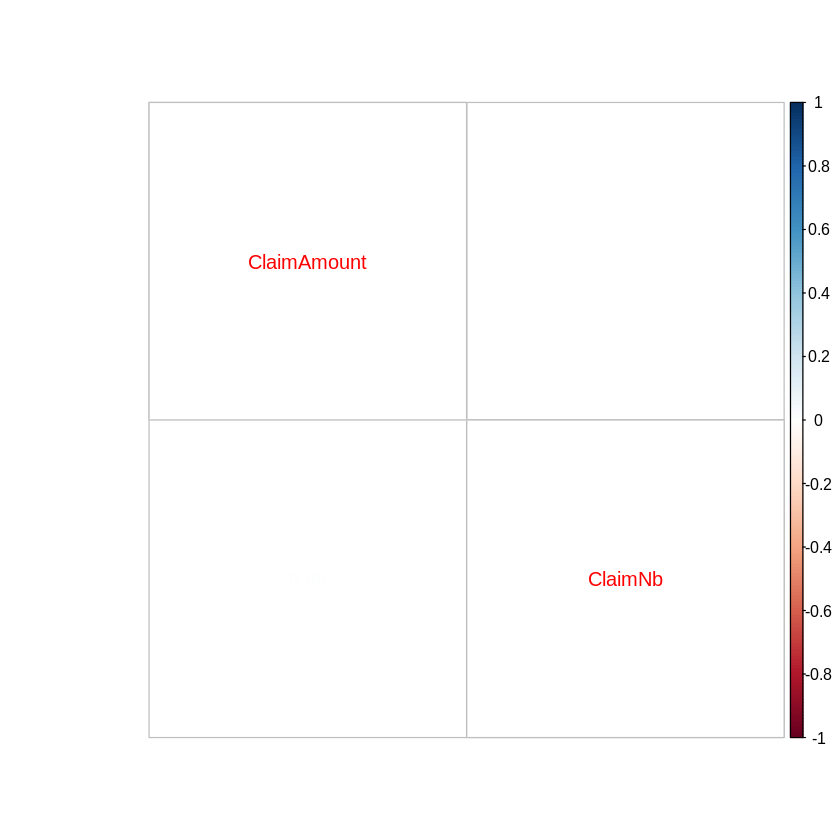

In [37]:

corrplot.mixed(corr.quanti.lineaire)




Ce bloc de code en R est utilisé pour calculer et afficher la matrice du V de Cramer, une mesure de l'association entre deux variables nominales (catégorielles).

In [38]:

library(questionr)
head(basecoutattri2)
matrice.Vcramer  <- matrix(NA, (ncol(basecoutattri2)-1), (ncol(basecoutattri2)-1))
for (i in 2:ncol(basecoutattri2))
{
  for (j in 2:ncol(basecoutattri2))
  {
    matrice.Vcramer[i-1,j-1] <- cramer.v(table(basecoutattri2[ ,i], basecoutattri2[ ,j]))
  }
}
colnames(matrice.Vcramer) <- rownames(matrice.Vcramer) <- colnames(basecoutattri2[,2:ncol(basecoutattri2)])
matrice.Vcramer

,PolicyID,ClaimAmount,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
,<int>,<int>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,33,302,1,0.75,g-h,"(-Inf,3]","(55,65]",Asian,Regular,IDF,"(5e+03,Inf]"
2,41,2001,1,0.14,l-o,"(3,5]","(45,55]",Asian,Diesel,PDL-BN-HN-LIM,"(0,100]"
3,92,1449,1,0.14,d,"(-Inf,3]","(30,45]",Asian,Regular,IDF,"(1e+03,5e+03]"
4,96,9924,2,0.62,i-j-k,"(-Inf,3]","(45,55]",Asian,Regular,IDF,"(5e+03,Inf]"
5,96,946,2,0.62,i-j-k,"(-Inf,3]","(45,55]",Asian,Regular,IDF,"(5e+03,Inf]"
6,142,1390,1,0.75,e,"(-Inf,3]","(30,45]",Asian,Regular,PC-NPDC-AQUIT,"(1e+03,5e+03]"


Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FALSE):
“Chi-squared approximation may be incorrect”
Warning message in stats::chisq.test(tab, correct = FAL

,ClaimAmount,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
ClaimAmount,1.0000000,0.51848785,0.49777666,0.46749835,0.46751856,0.46281960,0.47569810,0.46420669,0.46688848,0.46934687
ClaimNb,0.5184878,1.00000000,0.16469671,0.03272242,0.03126694,0.04843417,0.05197931,0.01122343,0.06766340,0.05531853
Exposure,0.4977767,0.16469671,1.00000000,0.08923099,0.11205777,0.14401461,0.19036775,0.09187981,0.14079514,0.12376441
Power,0.4674984,0.03272242,0.08923099,1.00000000,0.07886200,0.05395941,0.16962582,0.31683869,0.06353815,0.05216966
CarAge,0.4675186,0.03126694,0.11205777,0.07886200,1.00000000,0.05169173,0.22756260,0.13031113,0.11116624,0.07565664
DriverAge,0.4628196,0.04843417,0.14401461,0.05395941,0.05169173,1.00000000,0.07122655,0.10238491,0.04266130,0.04534771
Brand,0.4756981,0.05197931,0.19036775,0.16962582,0.22756260,0.07122655,1.00000000,0.06593212,0.21650488,0.15862768
Gas,0.4642067,0.01122343,0.09187981,0.31683869,0.13031113,0.10238491,0.06593212,1.00000000,0.10398693,0.14666651
Region,0.4668885,0.06766340,0.14079514,0.06353815,0.11116624,0.04266130,0.21650488,0.10398693,1.00000000,0.36667968
Density,0.4693469,0.05531853,0.12376441,0.05216966,0.07565664,0.04534771,0.15862768,0.14666651,0.36667968,1.00000000


Ce bloc de code R est une étape de préparation des données qui vise à identifier les variables catégorielles dans le dataframe basefreq2 et à définir un niveau de référence pour chacune d'entre elles

In [39]:



## -----------------------------------------------------------------------------------------------------
idCateg <- sapply(basefreq2, class) == "factor"
sapply(basefreq2, is.ordered)
idCateg["PolicyID"] <- FALSE
nameCateg <- colnames(basefreq2)[idCateg]
refCateg <- sapply(nameCateg, function(v)
  names(which.max(table(basefreq2[, v]))))
data.frame(variable = nameCateg, ref = refCateg)

for (v in nameCateg)
  print(levels(basefreq2[ , v]))

PolicyID    ClaimNb   Exposure      Power     CarAge  DriverAge      Brand 
     FALSE      FALSE      FALSE      FALSE      FALSE      FALSE      FALSE 
       Gas     Region    Density TotalClaim 
     FALSE      FALSE      FALSE      FALSE

,variable,ref
,<chr>,<chr>
Power,Power,g-h
CarAge,CarAge,"(-Inf,3]"
DriverAge,DriverAge,"(30,45]"
Brand,Brand,French
Gas,Gas,Regular
Region,Region,Centre
Density,Density,"(0,100]"


[1] "d"     "e"     "f"     "g-h"   "i-j-k" "l-o"   "m-n"  
[1] "(-Inf,3]"  "(3,5]"     "(5,9]"     "(9,11]"    "(11, Inf]"
[1] "(-Inf,30]" "(30,45]"   "(45,55]"   "(55,65]"   "(65, Inf]"
[1] "Italy Germany" "Asian"         "US"            "French"       
[1] "Diesel"  "Regular"
[1] "PC-NPDC-AQUIT" "PDL-BN-HN-LIM" "Bretagne"      "Centre"       
[5] "IDF"          
[1] "(0,100]"       "(100,500]"     "(500,1e+03]"   "(1e+03,5e+03]"
[5] "(5e+03,Inf]"  


In [40]:
## Mise a jour de la modalite de reference:
for (v in nameCateg)
{
  basecoutattri2[ , v] <- relevel(basecoutattri2[ , v], ref = refCateg[v])
  basefreq2[ , v] <- relevel(basefreq2[ , v], ref = refCateg[v])
  basecoutatyp2[ , v] <- relevel(basecoutatyp2[ , v], ref = refCateg[v])

}

idref <- apply(sapply(1:length(nameCateg), function(j)
  basefreq2[ , nameCateg[j]] == refCateg[nameCateg[j]]), 1, all)
NROW(basefreq2[idref, ])

[1] 215

In [41]:

## -----------------------------------------------------------------------------------------------------
set.seed(123)

prop <- 4/5
n <- NROW(basefreq2)
id.app <- sample(1:n, n*prop)

basefreq2.app <- basefreq2[id.app, ]
basefreq2.test <- basefreq2[-id.app, ]

ID.app <- sort(unique(basefreq2.app$PolicyID))

basecoutattri2.app <- basecoutattri2[basecoutattri2$PolicyID %in% ID.app, ]
basecoutattri2.test <- basecoutattri2[!basecoutattri2$PolicyID %in% ID.app, ]

basecoutatyp2.app <- basecoutatyp2[basecoutatyp2$PolicyID %in% ID.app, ]
basecoutatyp2.test <- basecoutatyp2[!basecoutatyp2$PolicyID %in% ID.app, ]

write.csv(basefreq2.app, file="basefreq2.app.csv", row.names = FALSE)
write.csv(basefreq2.test, file="basefreq2.test.csv", row.names = FALSE)

write.csv(basecoutattri2.app, file="basecoutattri2.app.csv", row.names = FALSE)
write.csv(basecoutattri2.test, file="basecoutattri2.test.csv", row.names = FALSE)

write.csv(basecoutatyp2.app, file="basecoutatyp2.app.csv", row.names = FALSE)
write.csv(basecoutatyp2.test, file="basecoutatyp2.test.csv", row.names = FALSE)


In [42]:
args(merge)
?merge


function (x, y, ...) 
NULL

In [43]:
## ---------------------------------------------------------------------------------------------

basefreq2.app <- read.csv(file="basefreq2.app.csv",
                          stringsAsFactors = TRUE, nrows = -1)
basefreq2.test <- read.csv(file="basefreq2.test.csv",
                           stringsAsFactors = TRUE, nrows = -1)


In [44]:
dim(basefreq2.app)
dim(basefreq2.test)

[1] 330164     11

[1] 82541    11

In [45]:


basefreq2.app.orig <- basefreq2.app

summary(basefreq2.app)



    PolicyID         ClaimNb           Exposure          Power      
 Min.   :     1   Min.   :0.00000   Min.   :0.002732   d    :54471  
 1st Qu.:103000   1st Qu.:0.00000   1st Qu.:0.200000   e    :61543  
 Median :206570   Median :0.00000   Median :0.530000   f    :76546  
 Mean   :206571   Mean   :0.03922   Mean   :0.560650   g-h  :94193  
 3rd Qu.:310196   3rd Qu.:0.00000   3rd Qu.:1.000000   i-j-k:35973  
 Max.   :413169   Max.   :4.00000   Max.   :1.000000   l-o  : 4955  
                                                       m-n  : 2483  
       CarAge           DriverAge                Brand             Gas        
 (-Inf,3] :103239   (-Inf,30]: 53310   Asian        : 63208   Diesel :164678  
 (11, Inf]: 84319   (30,45]  :122916   French       :174473   Regular:165486  
 (3,5]    : 39577   (45,55]  : 78773   Italy Germany: 54798                   
 (5,9]    : 68171   (55,65]  : 41764   US           : 37685                   
 (9,11]   : 34858   (65, Inf]: 33401                 

# 3. Modèles Fréquence

### 2.1 Formules

In [46]:
refCateg <- c("Power"= "g-h", "CarAge"="(-Inf,3]",
              "DriverAge"="(30,45]",
              "Brand"="French",
              "Gas"="Regular",
              "Region"="Centre",
              "Density"="(0,100]")

In [47]:
## Mise a jour de la modalite de reference:
for (v in names(refCateg))
{
  basefreq2.app[ , v] <- relevel(basefreq2.app[ , v], ref = refCateg[v])
  basefreq2.test[ , v] <- relevel(basefreq2.test[ , v], ref = refCateg[v])
}

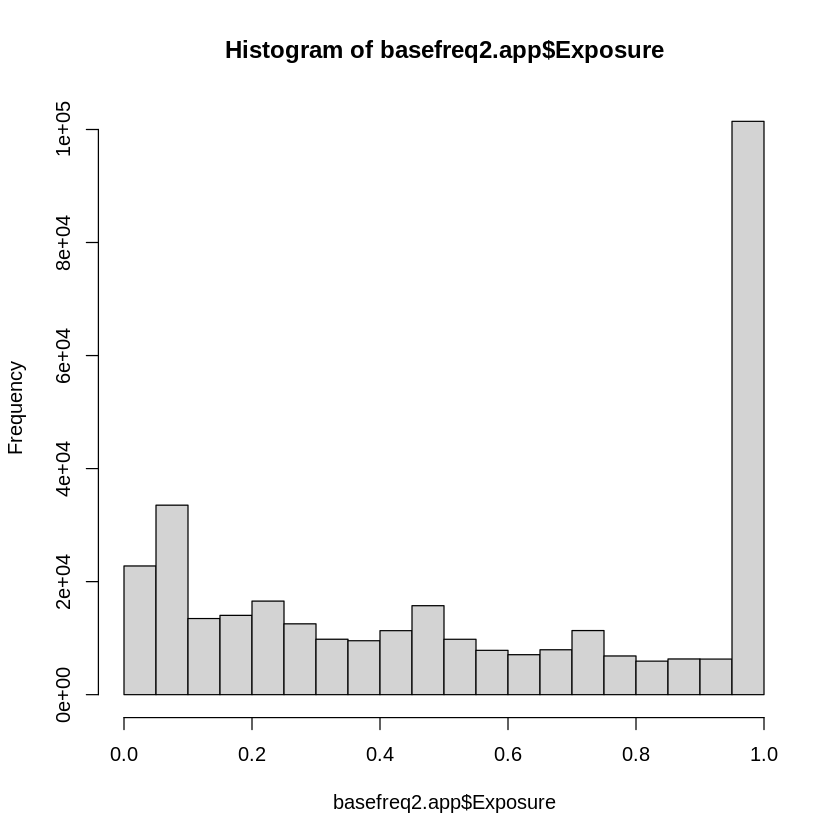

In [48]:
## ---------------------------------------------------------------------------------------------
freqform <- ClaimNb ~ Power + CarAge + DriverAge + Brand + Gas + Region + Density +  offset(log(Exposure))
freqform2 <- ClaimNb ~ Power + CarAge + DriverAge + Brand + Gas + Region + Density

hist(basefreq2.app$Exposure)

l'ajustement et l'analyse de modèles de régression de Poisson pour modéliser la fréquence des sinistres (ClaimNb)

### 2.2 GLM Poisson

In [49]:
#modele sans variables explicatives
pois0<-glm("ClaimNb ~ 1+offset(log(Exposure))",family=poisson("log"),data=basefreq2.app)


 une régression de Poisson

In [50]:
pois1 <- glm(freqform, family=poisson("log"),data=basefreq2.app)
summary(pois1)




Call:
glm(formula = freqform, family = poisson("log"), data = basefreq2.app)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.032712   0.035678 -85.001  < 2e-16 ***
Powerd               -0.091900   0.029079  -3.160 0.001576 ** 
Powere               -0.019711   0.026127  -0.754 0.450592    
Powerf               -0.008631   0.024765  -0.349 0.727443    
Poweri-j-k            0.121185   0.031560   3.840 0.000123 ***
Powerl-o              0.051121   0.078843   0.648 0.516735    
Powerm-n              0.074100   0.101858   0.727 0.466932    
CarAge(11, Inf]      -0.110273   0.027188  -4.056 4.99e-05 ***
CarAge(3,5]           0.001295   0.030543   0.042 0.966176    
CarAge(5,9]           0.037297   0.026391   1.413 0.157578    
CarAge(9,11]          0.036825   0.032122   1.146 0.251628    
DriverAge(-Inf,30]    0.423817   0.025301  16.751  < 2e-16 ***
DriverAge(45,55]      0.052166   0.023258   2.243 0.024902 *  
DriverAge(55,65]     -0.0

In [51]:
pois2 <- glm(freqform2, family=poisson("log"),data=basefreq2.app)
summary(pois2)






Call:
glm(formula = freqform2, family = poisson("log"), data = basefreq2.app)

Coefficients:
                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.553e+00  3.587e-02 -99.036  < 2e-16 ***
Powerd               -6.634e-02  2.904e-02  -2.284  0.02236 *  
Powere                1.819e-02  2.611e-02   0.697  0.48602    
Powerf                1.291e-02  2.480e-02   0.521  0.60264    
Poweri-j-k            8.157e-02  3.152e-02   2.588  0.00966 ** 
Powerl-o              4.317e-02  7.880e-02   0.548  0.58382    
Powerm-n             -6.607e-05  1.019e-01  -0.001  0.99948    
CarAge(11, Inf]      -1.767e-02  2.736e-02  -0.646  0.51827    
CarAge(3,5]           1.435e-01  3.058e-02   4.692 2.70e-06 ***
CarAge(5,9]           1.845e-01  2.651e-02   6.959 3.43e-12 ***
CarAge(9,11]          1.494e-01  3.222e-02   4.637 3.53e-06 ***
DriverAge(-Inf,30]    2.391e-01  2.528e-02   9.458  < 2e-16 ***
DriverAge(45,55]      1.456e-01  2.327e-02   6.258 3.89e-10 ***
DriverAge(

In [52]:
coef(summary(pois1))[order(coef(summary(pois1))[,4]),]


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-3.032711904,0.03567849,-85.00111687,0.000000e+00
"Density(1e+03,5e+03]",0.457282301,0.02535052,18.03837751,9.736066e-73
"DriverAge(-Inf,30]",0.423816735,0.02530143,16.75070595,5.595828e-63
"Density(5e+03,Inf]",0.522336491,0.04681552,11.15733726,6.593695e-29
GasDiesel,0.154304483,0.01903676,8.10560594,5.248329e-16
"Density(500,1e+03]",0.274399251,0.03460191,7.93017633,2.188349e-15
"Density(100,500]",0.170414976,0.02402949,7.09190907,1.322744e-12
BrandAsian,-0.192350598,0.03228904,-5.95714904,2.566762e-09
"CarAge(11, Inf]",-0.110273133,0.02718752,-4.05602039,4.991590e-05
Poweri-j-k,0.121185134,0.03155954,3.83988962,1.230896e-04


In [53]:
levels(basefreq2.app$Power)
table(basefreq2.app$Power)

levels(basefreq2.app$Power)=c("g-h","d","e-f","e-f","i-j-k","l-o","m-n"  )


[1] "g-h"   "d"     "e"     "f"     "i-j-k" "l-o"   "m-n"


  g-h     d     e     f i-j-k   l-o   m-n 
94193 54471 61543 76546 35973  4955  2483 

In [54]:
pois3 <- glm(freqform, family=poisson("log"),data=basefreq2.app)
summary(pois3)




Call:
glm(formula = freqform, family = poisson("log"), data = basefreq2.app)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.033326   0.035647 -85.093  < 2e-16 ***
Powerd               -0.091618   0.029071  -3.152 0.001624 ** 
Powere-f             -0.013658   0.021544  -0.634 0.526114    
Poweri-j-k            0.121354   0.031557   3.846 0.000120 ***
Powerl-o              0.051223   0.078843   0.650 0.515895    
Powerm-n              0.074597   0.101851   0.732 0.463917    
CarAge(11, Inf]      -0.109615   0.027141  -4.039 5.37e-05 ***
CarAge(3,5]           0.001796   0.030518   0.059 0.953068    
CarAge(5,9]           0.038201   0.026299   1.453 0.146345    
CarAge(9,11]          0.037652   0.032060   1.174 0.240218    
DriverAge(-Inf,30]    0.423561   0.025294  16.746  < 2e-16 ***
DriverAge(45,55]      0.052086   0.023257   2.240 0.025119 *  
DriverAge(55,65]     -0.081831   0.029827  -2.744 0.006078 ** 
DriverAge(65, Inf]   -0.0

In [55]:
basefreq2.app <- read.csv(file="basefreq2.app.csv",
                          stringsAsFactors = TRUE, nrows = -1)

levels(basefreq2.app$Power)=c("f-g-h","d","e","f-g-h","i-j-k","l-o","m-n"  )
levels(basefreq2.app$Power)

[1] "f-g-h" "d"     "e"     "i-j-k" "l-o"   "m-n"

In [56]:
pois4 <- glm(freqform, family=poisson("log"),data=basefreq2.app)
summary(pois4)


Call:
glm(formula = freqform, family = poisson("log"), data = basefreq2.app)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -2.677106   0.048455 -55.250  < 2e-16 ***
Powerd                0.011391   0.024322   0.468  0.63954    
Powere                0.020424   0.023125   0.883  0.37714    
Poweri-j-k            0.153650   0.029936   5.133 2.86e-07 ***
Powerl-o              0.081073   0.078308   1.035  0.30052    
Powerm-n              0.107820   0.101327   1.064  0.28729    
CarAge(11, Inf]      -0.110691   0.027201  -4.069 4.71e-05 ***
CarAge(3,5]           0.003720   0.030540   0.122  0.90305    
CarAge(5,9]           0.039210   0.026398   1.485  0.13745    
CarAge(9,11]          0.036343   0.032134   1.131  0.25806    
DriverAge(30,45]     -0.418870   0.025253 -16.587  < 2e-16 ***
DriverAge(45,55]     -0.367093   0.026909 -13.642  < 2e-16 ***
DriverAge(55,65]     -0.500049   0.032779 -15.255  < 2e-16 ***
DriverAge(65, Inf]   -0.4

In [57]:
# on regroupe finalement les modalités e et f qui presentent la même sinistralité

basefreq2.app <- read.csv(file="basefreq2.app.csv",
                          stringsAsFactors = TRUE, nrows = -1)

levels(basefreq2.app$Power)=c("g-h","d","e-f","e-f","i-j-k","l-o","m-n"  )
levels(basefreq2.app$Power)

[1] "g-h"   "d"     "e-f"   "i-j-k" "l-o"   "m-n"

In [58]:
## Mise a jour de la modalite de reference:
for (v in names(refCateg))
{
  basefreq2.app[ , v] <- relevel(basefreq2.app[ , v], ref = refCateg[v])
  basefreq2.test[ , v] <- relevel(basefreq2.test[ , v], ref = refCateg[v])
}

pois5 <- glm(freqform, family=poisson("log"),data=basefreq2.app)
summary(pois5)


Call:
glm(formula = freqform, family = poisson("log"), data = basefreq2.app)

Coefficients:
                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.1244028  0.0383889 -81.388  < 2e-16 ***
Powerd                0.0725257  0.0311546   2.328 0.019916 *  
Powere-f              0.0882350  0.0271223   3.253 0.001141 ** 
Poweri-j-k            0.2130939  0.0355002   6.003 1.94e-09 ***
Powerl-o              0.1429299  0.0807828   1.769 0.076842 .  
Powerm-n              0.1657354  0.1030348   1.609 0.107718    
CarAge(11, Inf]      -0.1102691  0.0271869  -4.056 4.99e-05 ***
CarAge(3,5]           0.0008908  0.0305206   0.029 0.976716    
CarAge(5,9]           0.0367253  0.0263394   1.394 0.163224    
CarAge(9,11]          0.0363968  0.0320986   1.134 0.256835    
DriverAge(-Inf,30]    0.4234829  0.0252831  16.750  < 2e-16 ***
DriverAge(45,55]      0.0522931  0.0232550   2.249 0.024533 *  
DriverAge(55,65]     -0.0816575  0.0298236  -2.738 0.006181 ** 
DriverAge(6

In [59]:
tapply(basefreq2.app$ClaimNb,basefreq2.app$Region,mean)

levels(basefreq2.app$Region)
levels(basefreq2.app$Region)<-c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")
levels(basefreq2.app$Region)

pois5 <- glm(freqform, family=poisson("log"),data=basefreq2.app)
summary(pois5)

Centre      Bretagne           IDF PC-NPDC-AQUIT PDL-BN-HN-LIM 
   0.04032622    0.04410894    0.03737947    0.03634955    0.03869714

[1] "Centre"        "Bretagne"      "IDF"           "PC-NPDC-AQUIT"
[5] "PDL-BN-HN-LIM"

[1] "C-B"           "IDF"           "PC-NPDC-AQUIT" "PDL-BN-HN-LIM"


Call:
glm(formula = freqform, family = poisson("log"), data = basefreq2.app)

Coefficients:
                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.1241149  0.0380832 -82.034  < 2e-16 ***
Powerd                0.0725316  0.0311545   2.328 0.019905 *  
Powere-f              0.0882252  0.0271218   3.253 0.001142 ** 
Poweri-j-k            0.2130752  0.0354988   6.002 1.95e-09 ***
Powerl-o              0.1429101  0.0807822   1.769 0.076880 .  
Powerm-n              0.1657365  0.1030349   1.609 0.107715    
CarAge(11, Inf]      -0.1103330  0.0271657  -4.061 4.88e-05 ***
CarAge(3,5]           0.0008958  0.0305205   0.029 0.976584    
CarAge(5,9]           0.0367179  0.0263391   1.394 0.163305    
CarAge(9,11]          0.0363739  0.0320963   1.133 0.257100    
DriverAge(-Inf,30]    0.4234578  0.0252796  16.751  < 2e-16 ***
DriverAge(45,55]      0.0522955  0.0232550   2.249 0.024526 *  
DriverAge(55,65]     -0.0816456  0.0298230  -2.738 0.006188 ** 
DriverAge(6

In [60]:
tapply(basefreq2.app$ClaimNb,basefreq2.app$CarAge,mean)

levels(basefreq2.app$CarAge)
levels(basefreq2.app$CarAge)<-c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]" ,"(9,11]" )

pois5 <- glm(freqform, family=poisson("log"),data=basefreq2.app)
summary(pois5)

(-Inf,3]  (11, Inf]      (3,5]      (5,9]     (9,11] 
0.03324325 0.03694304 0.04257523 0.04636869 0.04466693

[1] "(-Inf,3]"  "(11, Inf]" "(3,5]"     "(5,9]"     "(9,11]"


Call:
glm(formula = freqform, family = poisson("log"), data = basefreq2.app)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.12270    0.03806 -82.048  < 2e-16 ***
Powerd                0.07176    0.03115   2.304 0.021233 *  
Powere-f              0.08824    0.02712   3.254 0.001140 ** 
Poweri-j-k            0.21337    0.03550   6.011 1.85e-09 ***
Powerl-o              0.14243    0.08078   1.763 0.077870 .  
Powerm-n              0.16603    0.10303   1.611 0.107096    
CarAge(11, Inf]      -0.11135    0.02714  -4.102 4.10e-05 ***
CarAge(3,9]           0.02330    0.02382   0.978 0.327889    
CarAge(9,11]          0.03540    0.03208   1.104 0.269780    
DriverAge(-Inf,30]    0.42356    0.02528  16.755  < 2e-16 ***
DriverAge(45,55]      0.05204    0.02325   2.238 0.025236 *  
DriverAge(55,65]     -0.08205    0.02982  -2.751 0.005933 ** 
DriverAge(65, Inf]   -0.07845    0.03172  -2.473 0.013400 *  
BrandAsian           -0.19431    0.0321

In [61]:
levels(basefreq2.app$CarAge)<-c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]" )

pois5 <- glm(freqform, family=poisson("log"),data=basefreq2.app)
summary(pois5)


Call:
glm(formula = freqform, family = poisson("log"), data = basefreq2.app)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.12193    0.03801 -82.130  < 2e-16 ***
Powerd                0.07129    0.03113   2.290 0.022009 *  
Powere-f              0.08788    0.02711   3.242 0.001188 ** 
Poweri-j-k            0.21338    0.03550   6.011 1.84e-09 ***
Powerl-o              0.14201    0.08077   1.758 0.078736 .  
Powerm-n              0.16591    0.10303   1.610 0.107337    
CarAge(11, Inf]      -0.11161    0.02714  -4.113 3.91e-05 ***
CarAge(3,11]          0.02607    0.02285   1.141 0.253999    
DriverAge(-Inf,30]    0.42356    0.02528  16.755  < 2e-16 ***
DriverAge(45,55]      0.05187    0.02325   2.231 0.025682 *  
DriverAge(55,65]     -0.08223    0.02982  -2.758 0.005823 ** 
DriverAge(65, Inf]   -0.07879    0.03171  -2.485 0.012970 *  
BrandAsian           -0.19497    0.03209  -6.075 1.24e-09 ***
BrandItaly Germany    0.07174    0.0241

In [62]:
# CarAge — gom 2 lần như basefreq2.test
levels(basefreq2.app$CarAge)       <- c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]","(9,11]")
levels(basefreq2.app$CarAge)       <- c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]")

levels(basefreq2.test$CarAge)      <- c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]","(9,11]")
levels(basefreq2.test$CarAge)      <- c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]")

levels(basecoutattri2.app$CarAge)  <- c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]","(9,11]")
levels(basecoutattri2.app$CarAge)  <- c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]")

levels(basecoutattri2.test$CarAge) <- c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]","(9,11]")
levels(basecoutattri2.test$CarAge) <- c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]")

# Region
levels(basefreq2.app$Region)       <- c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")
levels(basefreq2.test$Region)      <- c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")
levels(basecoutattri2.app$Region)  <- c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")
levels(basecoutattri2.test$Region) <- c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")

# Power
levels(basefreq2.app$Power)        <- c("g-h","d","e-f","e-f","i-j-k","l-o","m-n")
levels(basefreq2.test$Power)       <- c("g-h","d","e-f","e-f","i-j-k","l-o","m-n")
levels(basecoutattri2.app$Power)   <- c("g-h","d","e-f","e-f","i-j-k","l-o","m-n")
levels(basecoutattri2.test$Power)  <- c("g-h","d","e-f","e-f","i-j-k","l-o","m-n")

# Kiểm tra tất cả đồng bộ
cat("CarAge app  :", levels(basefreq2.app$CarAge), "\n")
cat("CarAge test :", levels(basefreq2.test$CarAge), "\n")
cat("CarAge sev.app  :", levels(basecoutattri2.app$CarAge), "\n")
cat("CarAge sev.test :", levels(basecoutattri2.test$CarAge), "\n")

cat("Region app  :", levels(basefreq2.app$Region), "\n")
cat("Region sev.app  :", levels(basecoutattri2.app$Region), "\n")

CarAge app  : (-Inf,3] (11, Inf] (3,11] 
CarAge test : (-Inf,3] (11, Inf] (3,11] 
CarAge sev.app  : (-Inf,3] (11, Inf] (3,11] 
CarAge sev.test : (-Inf,3] (11, Inf] (3,11] 
Region app  : C-B IDF PC-NPDC-AQUIT PDL-BN-HN-LIM 
Region sev.app  : C-B IDF PC-NPDC-AQUIT PDL-BN-HN-LIM 


[1] 12950

[1] 12950

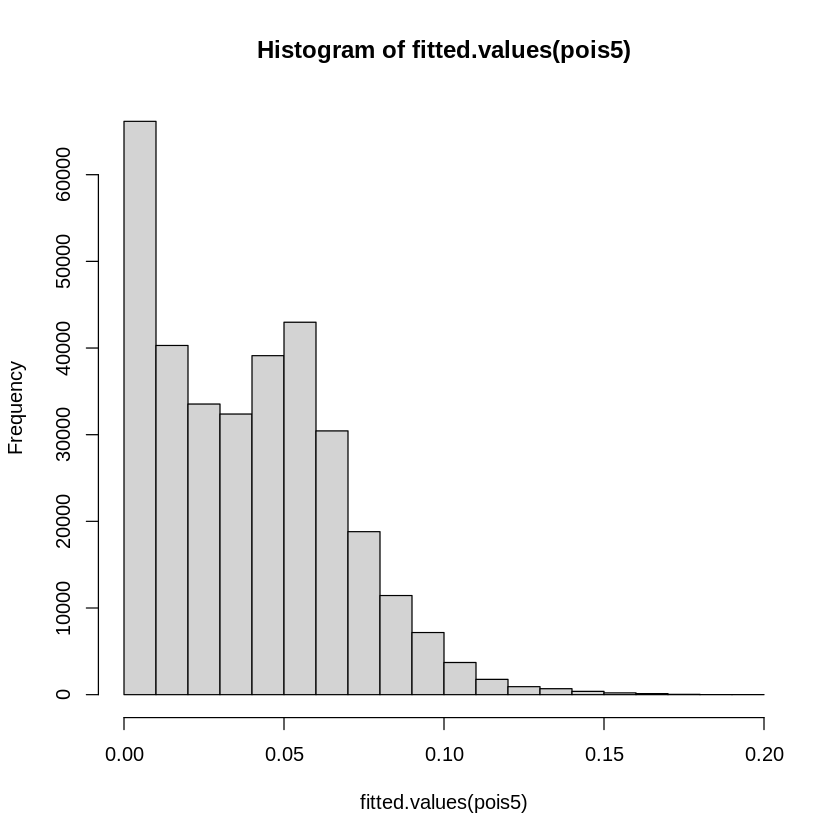

In [63]:

sum(basefreq2.app$ClaimNb)
sum(fitted.values(pois5))
hist(fitted.values(pois5))

In [64]:
#calcul erroné
mean(basefreq2.app$ClaimNb)

[1] 0.03922293

In [65]:

# il faut prendre en compte l'exposition !
sum(basefreq2.app$ClaimNb)/sum(basefreq2.app$Exposure)

[1] 0.06995971

In [66]:
mean(fitted.values(pois5)) #predict pour les donnes apprentissage avec l'exposition observee (pas unitaire)


[1] 0.03922293

In [67]:
basefreqExpo1<-basefreq2.app
basefreqExpo1$Exposure<-1
lambdachap<-predict(pois5,newdata =basefreqExpo1,type="response" )

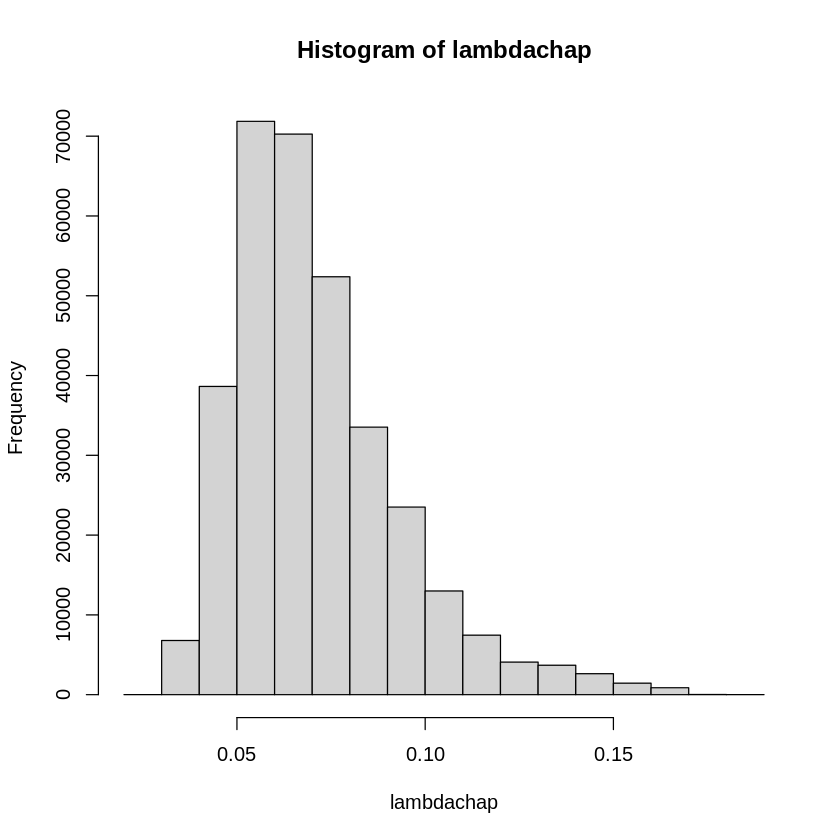

In [68]:
hist(lambdachap)


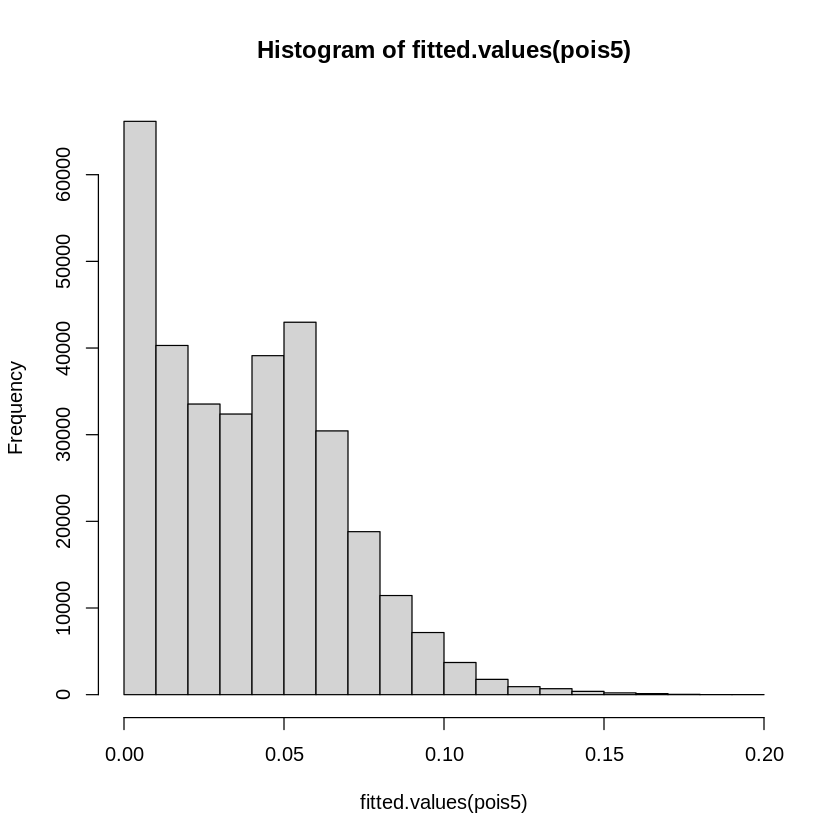

In [69]:
hist(fitted.values(pois5))


In [70]:
mean(lambdachap) #coherent avec la moyenne historique


[1] 0.07110406

In [71]:
sum(basefreq2.app$ClaimNb)/sum(basefreq2.app$Exposure)

[1] 0.06995971

In [72]:
# sur la base test

levels(basefreq2.test$Power)=c("g-h","d","e-f","e-f","i-j-k","l-o","m-n"  )
levels(basefreq2.test$Region)<-c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")
levels(basefreq2.test$CarAge)<-c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]" ,"(9,11]" )
levels(basefreq2.test$CarAge)<-c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]" )

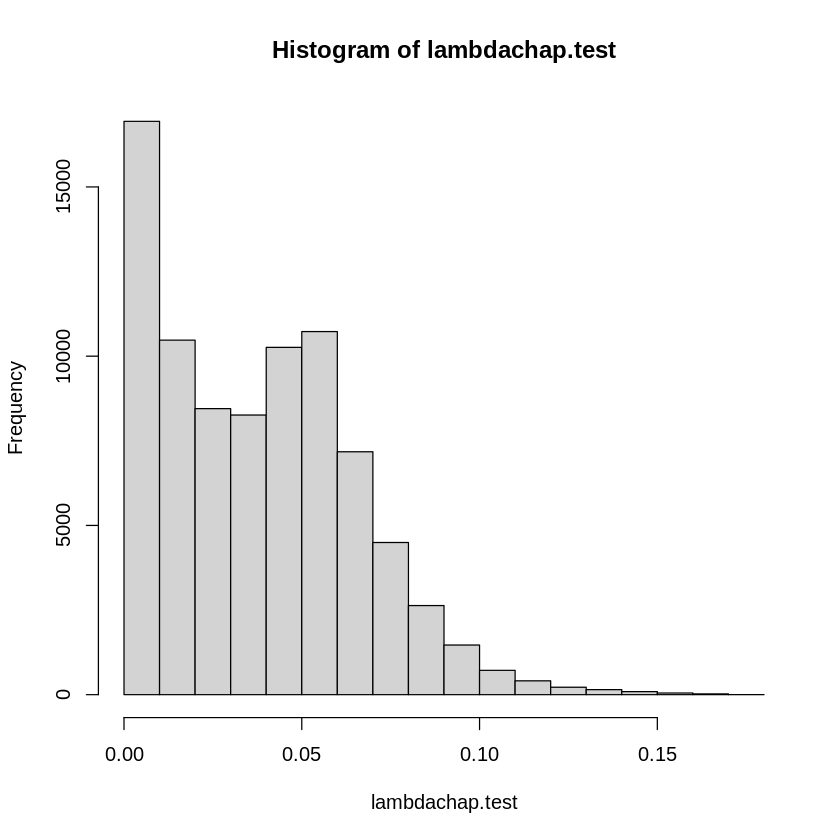

In [73]:
lambdachap.test<-predict(pois5,newdata =basefreq2.test,type="response" )
hist(lambdachap.test)


In [74]:
lambda0.test<-predict(pois0,newdata =basefreq2.test,type="response" )


In [75]:
RMSE <- function(x, y)
  sqrt(mean((x-y)^2))

RMSE(basefreq2.test$ClaimNb,lambdachap.test)
RMSE(basefreq2.test$ClaimNb,lambda0.test)

[1] 0.2017698

[1] 0.2021299

### 2.3 Binomiale Négative

In [76]:
################# Binomiale negative ##########

library(MASS)
negbinom1 <- glm(freqform, family=negative.binomial(1),data=basefreq2.app)
summary(negbinom1)


Call:
glm(formula = freqform, family = negative.binomial(1), data = basefreq2.app)

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          -3.11598    0.05047 -61.734  < 2e-16 ***
Powerd                0.07554    0.04151   1.820  0.06882 .  
Powere-f              0.11222    0.03524   3.184  0.00145 ** 
Poweri-j-k            0.14135    0.10781   1.311  0.18983    
Powerl-o              0.15808    0.13817   1.144  0.25258    
CarAge(11, Inf]      -0.10698    0.03614  -2.960  0.00308 ** 
CarAge(3,11]          0.02680    0.03053   0.878  0.38013    
DriverAge(-Inf,30]    0.42660    0.03384  12.606  < 2e-16 ***
DriverAge(45,55]      0.05376    0.03104   1.732  0.08327 .  
DriverAge(55,65]     -0.08458    0.03975  -2.128  0.03335 *  
DriverAge(65, Inf]   -0.08737    0.04223  -2.069  0.03855 *  
BrandAsian           -0.16261    0.04123  -3.944 8.02e-05 ***
BrandItaly Germany    0.08383    0.03218   2.605  0.00918 ** 
BrandUS               0.10999    

In [77]:


negbinom2 <- glm.nb(freqform, data=basefreq2.app)
summary(negbinom2)






Call:
glm.nb(formula = freqform, data = basefreq2.app, init.theta = 0.7976863444, 
    link = log)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.11549    0.03899 -79.910  < 2e-16 ***
Powerd                0.07556    0.03207   2.356 0.018481 *  
Powere-f              0.11221    0.02722   4.123 3.75e-05 ***
Poweri-j-k            0.14134    0.08330   1.697 0.089754 .  
Powerl-o              0.15684    0.10686   1.468 0.142191    
CarAge(11, Inf]      -0.10615    0.02792  -3.802 0.000144 ***
CarAge(3,11]          0.02735    0.02360   1.159 0.246449    
DriverAge(-Inf,30]    0.42826    0.02617  16.366  < 2e-16 ***
DriverAge(45,55]      0.05425    0.02398   2.262 0.023697 *  
DriverAge(55,65]     -0.08477    0.03070  -2.761 0.005761 ** 
DriverAge(65, Inf]   -0.08764    0.03262  -2.687 0.007220 ** 
BrandAsian           -0.16321    0.03184  -5.126 2.96e-07 ***
BrandItaly Germany    0.08401    0.02488   3.377 0.000733 ***
BrandUS          

In [78]:
negbinom3 <- glm.nb(freqform, data=basefreq2.app.orig)
summary(negbinom3)


Call:
glm.nb(formula = freqform, data = basefreq2.app.orig, init.theta = 0.8012100789, 
    link = log)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -2.729016   0.053729 -50.792  < 2e-16 ***
Powere                0.072572   0.032126   2.259  0.02389 *  
Powerf                0.084037   0.031580   2.661  0.00779 ** 
Powerg-h              0.091660   0.029940   3.061  0.00220 ** 
Poweri-j-k            0.212305   0.036632   5.796 6.81e-09 ***
Powerl-o              0.142750   0.083318   1.713  0.08665 .  
Powerm-n              0.160302   0.106839   1.500  0.13351    
CarAge(11, Inf]      -0.105819   0.028033  -3.775  0.00016 ***
CarAge(3,5]           0.002074   0.031573   0.066  0.94761    
CarAge(5,9]           0.039910   0.027301   1.462  0.14379    
CarAge(9,11]          0.042825   0.033197   1.290  0.19704    
DriverAge(30,45]     -0.432290   0.026204 -16.497  < 2e-16 ***
DriverAge(45,55]     -0.377463   0.027909 -13.525  < 2e-16 **

In [79]:
anova(negbinom2)




Warning message in anova.negbin(negbinom2):
“tests made without re-estimating 'theta'”


,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,330163,72403.43,NA
Power,4,30.25710,330159,72373.18,4.338604e-06
CarAge,2,67.32752,330157,72305.85,2.398917e-15
DriverAge,4,435.55080,330153,71870.30,5.772221e-93
Brand,3,50.48830,330150,71819.81,6.287823e-11
Gas,1,20.10163,330149,71799.71,7.343393e-06
Region,2,14.21122,330147,71785.50,8.204901e-04
Density,4,471.91187,330143,71313.58,7.948898e-101


In [80]:
anova(pois5)



,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,330163,84436.37,NA
Power,5,44.28902,330158,84392.08,2.023471e-08
CarAge,2,76.60095,330156,84315.48,2.324419e-17
DriverAge,4,453.41361,330152,83862.06,7.940739e-97
Brand,3,49.80468,330149,83812.26,8.792190e-11
Gas,1,25.88030,330148,83786.38,3.632571e-07
Region,3,177.66817,330145,83608.71,2.812011e-38
Density,4,346.02009,330141,83262.69,1.268431e-73


In [81]:
gofstat <- function(x)
  c("loglik"=logLik(x),"AIC"= AIC(x),"BIC"= BIC(x), "deviance"=deviance(x))
cbind("poisson"=gofstat(pois5), "nbinom"= gofstat(negbinom2))

,poisson,nbinom
loglik,-54130.46,-53975.35
AIC,108306.91,107994.70
BIC,108553.18,108230.26
deviance,83262.69,71313.58


In [82]:
sum(basefreq2.app$ClaimNb)/sum(basefreq2.app$Exposure) #moyenne


[1] 0.06995971

In [83]:
sum(basefreq2.app$ClaimNb^2)/sum(basefreq2.app$Exposure)-sum(basefreq2.app$ClaimNb)/sum(basefreq2.app$Exposure)^2 #variance


[1] 0.07729565

In [84]:
c(mean(basefreq2.app$ClaimNb),var(basefreq2.app$ClaimNb))

[1] 0.03922293 0.04179773

In [85]:
#comparaison des predictions

levels(basefreq2.test$Power)=c("g-h","d","e-f","e-f","i-j-k","l-o","m-n"  )
levels(basefreq2.test$Region)<-c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")
levels(basefreq2.test$CarAge)<-c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]" ,"(9,11]" )
levels(basefreq2.test$CarAge)<-c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]" )



In [86]:
basefreq2.test$poisson.pred.test<-predict(pois5,newdata =basefreq2.test,type="response" )
basefreq2.test$negbinom.pred.test<-predict(negbinom2,newdata =basefreq2.test,type="response" )



In [87]:
head(basefreq2.test)




,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,TotalClaim,poisson.pred.test,negbinom.pred.test
,<int>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>
1,2,0,0.84,g-h,"(-Inf,3]","(45,55]",Asian,Diesel,C-B,"(0,100]",0,0.037408491,0.038576589
2,11,0,0.10,e-f,"(-Inf,3]","(30,45]",Asian,Diesel,C-B,"(0,100]",0,0.004616666,0.004866517
3,12,0,0.77,e-f,"(-Inf,3]","(30,45]",Asian,Diesel,C-B,"(0,100]",0,0.035548328,0.037472184
4,14,0,0.19,e-f,"(-Inf,3]","(30,45]",Asian,Regular,C-B,"(1e+03,5e+03]",0,0.011885866,0.012867425
5,19,0,0.12,e-f,"(-Inf,3]","(30,45]",Asian,Regular,C-B,"(5e+03,Inf]",0,0.008009630,0.009244989
6,25,0,0.87,e-f,"(-Inf,3]","(65, Inf]",Asian,Regular,C-B,"(100,500]",0,0.037758466,0.039951298


In [88]:
summary(basefreq2.test$poisson.pred.test-basefreq2.test$negbinom.pred.test)


      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-0.0207292 -0.0018270 -0.0008274 -0.0013694 -0.0002428  0.0066940 

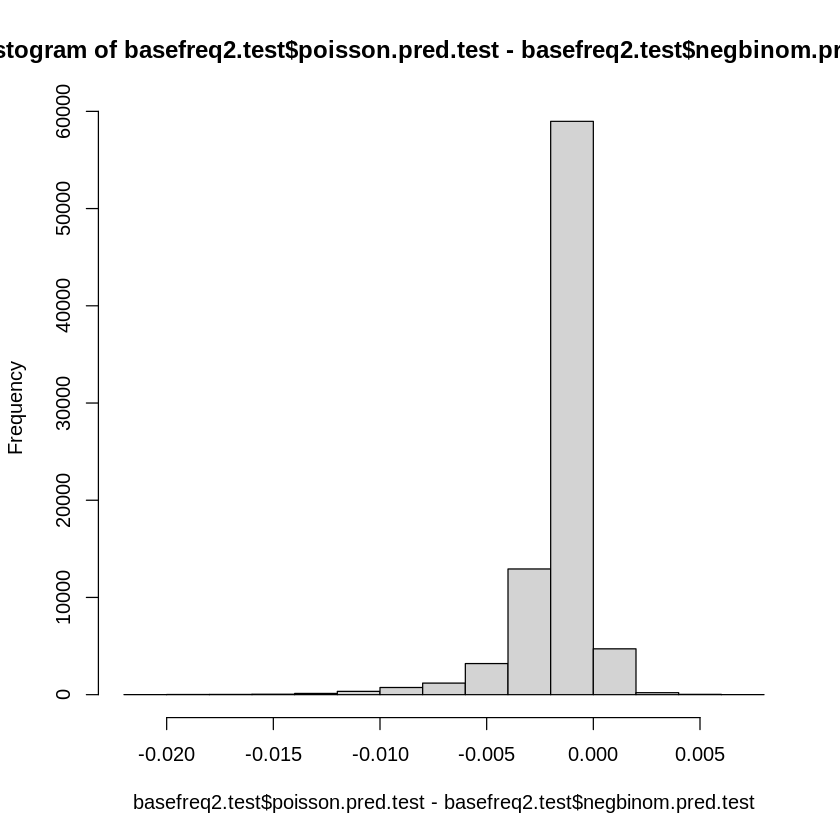

In [89]:
hist(basefreq2.test$poisson.pred.test-basefreq2.test$negbinom.pred.test)

In [90]:
subset(basefreq2.test,basefreq2.test$poisson.pred.test-basefreq2.test$negbinom.pred.test<.002)


,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,TotalClaim,poisson.pred.test,negbinom.pred.test
,<int>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>
1,2,0,0.84,g-h,"(-Inf,3]","(45,55]",Asian,Diesel,C-B,"(0,100]",0,0.037408491,0.038576589
2,11,0,0.10,e-f,"(-Inf,3]","(30,45]",Asian,Diesel,C-B,"(0,100]",0,0.004616666,0.004866517
3,12,0,0.77,e-f,"(-Inf,3]","(30,45]",Asian,Diesel,C-B,"(0,100]",0,0.035548328,0.037472184
4,14,0,0.19,e-f,"(-Inf,3]","(30,45]",Asian,Regular,C-B,"(1e+03,5e+03]",0,0.011885866,0.012867425
5,19,0,0.12,e-f,"(-Inf,3]","(30,45]",Asian,Regular,C-B,"(5e+03,Inf]",0,0.008009630,0.009244989
6,25,0,0.87,e-f,"(-Inf,3]","(65, Inf]",Asian,Regular,C-B,"(100,500]",0,0.037758466,0.039951298
7,28,0,0.72,e-f,"(-Inf,3]","(30,45]",Asian,Regular,C-B,"(500,1e+03]",0,0.037522248,0.040402401
8,40,0,0.55,e-f,"(3,11]","(45,55]",Asian,Diesel,IDF,"(0,100]",0,0.030095047,0.031270999
9,42,0,0.77,g-h,"(3,11]","(30,45]",Italy Germany,Diesel,C-B,"(0,100]",0,0.043631969,0.044078116


In [91]:
summary(subset(basefreq2.test,basefreq2.test$poisson.pred.test-basefreq2.test$negbinom.pred.test<.002))


    PolicyID         ClaimNb           Exposure          Power      
 Min.   :     2   Min.   :0.00000   Min.   :0.002732   g-h  :23571  
 1st Qu.:104025   1st Qu.:0.00000   1st Qu.:0.200000   d    :13487  
 Median :207452   Median :0.00000   Median :0.530000   e-f  :44839  
 Mean   :207023   Mean   :0.03877   Mean   :0.559120   i-j-k:  403  
 3rd Qu.:309166   3rd Qu.:0.00000   3rd Qu.:1.000000   l-o  :    0  
 Max.   :413166   Max.   :3.00000   Max.   :1.000000   m-n  :    0  
       CarAge          DriverAge               Brand            Gas       
 (-Inf,3] :25597   (30,45]  :30469   French       :43390   Regular:41308  
 (11, Inf]:21120   (-Inf,30]:13540   Asian        :15829   Diesel :40992  
 (3,11]   :35583   (45,55]  :19603   Italy Germany:13575                  
                   (55,65]  :10319   US           : 9506                  
                   (65, Inf]: 8369                                        
                                                                   

In [92]:
summary(subset(basefreq2.test,basefreq2.test$poisson.pred.test-basefreq2.test$negbinom.pred.test>0))

    PolicyID         ClaimNb           Exposure          Power     
 Min.   :  2364   Min.   :0.00000   Min.   :0.002732   g-h  :3650  
 1st Qu.: 92322   1st Qu.:0.00000   1st Qu.:0.250000   d    : 678  
 Median :188911   Median :0.00000   Median :0.760000   e-f  :  76  
 Mean   :192013   Mean   :0.03774   Mean   :0.641252   i-j-k: 551  
 3rd Qu.:288982   3rd Qu.:0.00000   3rd Qu.:1.000000   l-o  :   0  
 Max.   :413042   Max.   :2.00000   Max.   :1.000000   m-n  :   0  
       CarAge         DriverAge              Brand           Gas      
 (-Inf,3] :1349   (30,45]  :1950   French       :4080   Regular:1619  
 (11, Inf]:1078   (-Inf,30]: 290   Asian        :  39   Diesel :3336  
 (3,11]   :2528   (45,55]  : 831   Italy Germany: 623                 
                  (55,65]  : 942   US           : 213                 
                  (65, Inf]: 942                                      
                                                                      
           Region          

In [93]:

library(pscl)
?zeroinfl
?hurdle

Classes and Methods for R originally developed in the
Political Science Computational Laboratory
Department of Political Science
Stanford University (2002-2015),
by and under the direction of Simon Jackman.
hurdle and zeroinfl functions by Achim Zeileis.



In [94]:
zipois1<- zeroinfl(freqform, data= basefreq2.app, dist="poisson", link = "logit")
summary(zipois1)




Call:
zeroinfl(formula = freqform, data = basefreq2.app, dist = "poisson", 
    link = "logit")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.3408 -0.2204 -0.1894 -0.1371 68.1370 

Count model coefficients (poisson with log link):
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -2.25053    0.09391 -23.964  < 2e-16 ***
Powerd               -0.06675    0.07891  -0.846  0.39758    
Powere-f             -0.05396    0.06804  -0.793  0.42777    
Poweri-j-k            0.00116    0.19147   0.006  0.99516    
Powerl-o             -0.16764    0.23466  -0.714  0.47498    
CarAge(11, Inf]       0.39508    0.06992   5.650 1.60e-08 ***
CarAge(3,11]          0.24591    0.05852   4.202 2.65e-05 ***
DriverAge(-Inf,30]    0.53657    0.06312   8.500  < 2e-16 ***
DriverAge(45,55]      0.07855    0.05827   1.348  0.17768    
DriverAge(55,65]      0.01283    0.07611   0.169  0.86616    
DriverAge(65, Inf]    0.13411    0.08661   1.548  0.12154    
BrandA

### 2.4 ZIP (Zéro-Inflaté)

In [95]:
#nouveau type de formule
freqformZI <- "ClaimNb ~ CarAge + DriverAge + Brand + Gas +
    Density + offset(log(Exposure)) | Power + CarAge + DriverAge+Brand + Gas +
    Density + offset(log(Exposure))"
zipois2<- zeroinfl(formula(freqformZI), data= basefreq2.app, dist="poisson", link = "logit")
summary(zipois2)




Call:
zeroinfl(formula = formula(freqformZI), data = basefreq2.app, dist = "poisson", 
    link = "logit")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.3360 -0.2212 -0.1895 -0.1372 67.4638 

Count model coefficients (poisson with log link):
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -2.30597    0.07810 -29.525  < 2e-16 ***
CarAge(11, Inf]       0.39048    0.06960   5.611 2.02e-08 ***
CarAge(3,11]          0.23883    0.05848   4.084 4.43e-05 ***
DriverAge(-Inf,30]    0.54274    0.06307   8.606  < 2e-16 ***
DriverAge(45,55]      0.08542    0.05773   1.480  0.13895    
DriverAge(55,65]      0.02314    0.07597   0.305  0.76069    
DriverAge(65, Inf]    0.14319    0.08643   1.657  0.09757 .  
BrandAsian           -0.16402    0.07804  -2.102  0.03558 *  
BrandItaly Germany    0.04386    0.05789   0.758  0.44862    
BrandUS               0.17478    0.06658   2.625  0.00867 ** 
GasDiesel             0.01123    0.04597   0.244  0.80708

In [96]:
cbind("zip1"=gofstat(zipois1), "zip2"= gofstat(zipois2))



##### Ces modeles doivent etre affines et ensuite compares grace a gofstat !! On suppose

,zip1,zip2
loglik,-53428.42,-53431.53
AIC,106940.85,106931.06
BIC,107390.56,107295.11


In [97]:
ZINB1 <- zeroinfl(formula(freqformZI), data= basefreq2.app, dist="negbin", link = "logit")
summary(ZINB1)



Warning message in sqrt(diag(vc)[np]):
“NaNs produced”



Call:
zeroinfl(formula = formula(freqformZI), data = basefreq2.app, dist = "negbin", 
    link = "logit")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.3360 -0.2212 -0.1896 -0.1372 67.4638 

Count model coefficients (negbin with log link):
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -2.30611    0.07810 -29.526  < 2e-16 ***
CarAge(11, Inf]       0.39057    0.06960   5.612 2.00e-08 ***
CarAge(3,11]          0.23885    0.05848   4.084 4.42e-05 ***
DriverAge(-Inf,30]    0.54280    0.06307   8.606  < 2e-16 ***
DriverAge(45,55]      0.08551    0.05773   1.481  0.13854    
DriverAge(55,65]      0.02323    0.07598   0.306  0.75977    
DriverAge(65, Inf]    0.14328    0.08643   1.658  0.09736 .  
BrandAsian           -0.16394    0.07805  -2.101  0.03568 *  
BrandItaly Germany    0.04384    0.05789   0.757  0.44882    
BrandUS               0.17483    0.06658   2.626  0.00865 ** 
GasDiesel             0.01122    0.04598   0.244  0.80717  

### 2.5 Hurdle (Zéro-Tronqué)

In [98]:
ZMP1 <- hurdle(freqform, data= basefreq2.app, dist="poisson", link = "logit")
summary(ZMP1)


Call:
hurdle(formula = freqform, data = basefreq2.app, dist = "poisson", link = "logit")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.3906 -0.2338 -0.1831 -0.1044 95.9260 

Count model coefficients (truncated poisson with log link):
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -2.435375   0.166197 -14.654  < 2e-16 ***
Powerd               -0.150929   0.129188  -1.168 0.242689    
Powere-f             -0.240809   0.108705  -2.215 0.026744 *  
Poweri-j-k           -0.423631   0.366081  -1.157 0.247188    
Powerl-o             -0.180780   0.455014  -0.397 0.691141    
CarAge(11, Inf]      -0.078610   0.121527  -0.647 0.517726    
CarAge(3,11]         -0.081114   0.097045  -0.836 0.403245    
DriverAge(-Inf,30]    0.771971   0.103886   7.431 1.08e-13 ***
DriverAge(45,55]     -0.131510   0.117382  -1.120 0.262559    
DriverAge(55,65]      0.086950   0.135840   0.640 0.522111    
DriverAge(65, Inf]    0.354586   0.130539   2.716 0.00

In [99]:

# que l'on garde le modele ZIP

basefreq2.test$zipoisson.pred.test<-predict(zipois2,newdata =basefreq2.test,type="response" )


# varlist <- c("Power",      "CarAge",     "DriverAge" ,
#             "Brand",      "Gas",        "Region",     "Density")

#graphSinistre(varlist[1], expo="Exposure", "ClaimNb", texte="Frequence", base=basefreq2.test, continu = FALSE)

#for(j in 1:7)
#{
#par(mfrow=1:2)
 # graphSinistre(varlist[j], expo="Exposure", "ClaimNb", texte="Frequence", base=basefreq2.test, continu = FALSE)
  #graphSinistre(varlist[j], "Exposure", "zipoisson.pred.test", texte="Frequence", base=basefreq2.test, continu = FALSE)
  #}

In [100]:
# ============================================================
# 2.6 Comparaison & Choix du modèle fréquence
# ============================================================

# --- Bảng so sánh AIC/BIC/loglik ---
cbind("poisson" = gofstat(pois5),
      "nbinom"  = gofstat(negbinom2),
      "zip"     = gofstat(zipois2),
      "hurdle"  = gofstat(ZMP1))

# --- Kiểm tra surdispersion ---
mean_freq <- sum(basefreq2.app$ClaimNb) / sum(basefreq2.app$Exposure)
var_freq  <- sum(basefreq2.app$ClaimNb^2) / sum(basefreq2.app$Exposure) -
             (sum(basefreq2.app$ClaimNb) / sum(basefreq2.app$Exposure))^2

cat("Mean     :", mean_freq, "\n")
cat("Variance :", var_freq,  "\n")
cat("Variance > Mean ?", var_freq > mean_freq, "\n")

# --- RMSE trên base test (Exposure thực tế) ---
freq.pois.real <- predict(pois5,     newdata=basefreq2.test, type="response")
freq.nb.real   <- predict(negbinom2, newdata=basefreq2.test, type="response")
freq.zip.real  <- predict(zipois2,   newdata=basefreq2.test, type="response")
freq.zmp.real  <- predict(ZMP1,      newdata=basefreq2.test, type="response")

# Kiểm tra scale — tất cả phải gần mean(ClaimNb)
cat("mean freq.pois :", mean(freq.pois.real), "\n")
cat("mean freq.nb   :", mean(freq.nb.real),   "\n")
cat("mean freq.zip  :", mean(freq.zip.real),  "\n")
cat("mean freq.zmp  :", mean(freq.zmp.real),  "\n")
cat("mean ClaimNb   :", mean(basefreq2.test$ClaimNb), "\n")

# Bảng RMSE
rmse_results <- data.frame(
  Model = c("Poisson", "NB", "ZIP", "Hurdle"),
  RMSE  = c(
    RMSE(basefreq2.test$ClaimNb, freq.pois.real),
    RMSE(basefreq2.test$ClaimNb, freq.nb.real),
    RMSE(basefreq2.test$ClaimNb, freq.zip.real),
    RMSE(basefreq2.test$ClaimNb, freq.zmp.real)
  )
)
print(rmse_results)

# --- Kết luận ---
# Dựa trên AIC/BIC → model thấp nhất
# Dựa trên RMSE    → model thấp nhất
# → Chọn model fréquence cuối cùng

# Lưu dự báo fréquence annuelle (Exposure = 1) cho bước tính prime pure
basefreq2.test.expo1          <- basefreq2.test
basefreq2.test.expo1$Exposure <- 1

basefreq2.test$freq.pred <- predict(zipois2,   # thay bằng model được chọn
                                    newdata=basefreq2.test.expo1,
                                    type="response")

Warning message in cbind(poisson = gofstat(pois5), nbinom = gofstat(negbinom2), :
“number of rows of result is not a multiple of vector length (arg 3)”


,poisson,nbinom,zip,hurdle
loglik,-54130.46,-53975.35,-53431.53,-53903.72
AIC,108306.91,107994.70,106931.06,107891.44
BIC,108553.18,108230.26,107295.11,108341.15
deviance,83262.69,71313.58,-53431.53,-53903.72


Mean     : 0.06995971 
Variance : 0.07240166 
Variance > Mean ? TRUE 
mean freq.pois : 0.03746609 
mean freq.nb   : 0.03883547 
mean freq.zip  : 0.03886476 
mean freq.zmp  : 0.03874243 
mean ClaimNb   : 0.03891399 
    Model      RMSE
1 Poisson 0.2017538
2      NB 0.2018017
3     ZIP 0.2014740
4  Hurdle 0.2018031


Variance lớn hơn Mean nhưng chênh lệch rất nhỏ (~3%) → surdispersion tồn tại nhưng không nghiêm trọng. NB có lý về mặt lý thuyết nhưng cải thiện không nhiều so với Poisson.



=> Dùng ZIP vì AIC,BIC thấp nhất



# 4. Modèles Sévérité

In [101]:
#################### Analyse de la severite ###############

basecoutattri2.app <- read.csv(file="basecoutattri2.app.csv",
                               stringsAsFactors = TRUE)
basecoutattri2.test <- read.csv(file="basecoutattri2.test.csv",
                                stringsAsFactors = TRUE)
head(basecoutattri2.app)

,PolicyID,ClaimAmount,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
,<int>,<int>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,33,302,1,0.75,g-h,"(-Inf,3]","(55,65]",Asian,Regular,IDF,"(5e+03,Inf]"
2,41,2001,1,0.14,l-o,"(3,5]","(45,55]",Asian,Diesel,PDL-BN-HN-LIM,"(0,100]"
3,96,9924,2,0.62,i-j-k,"(-Inf,3]","(45,55]",Asian,Regular,IDF,"(5e+03,Inf]"
4,96,946,2,0.62,i-j-k,"(-Inf,3]","(45,55]",Asian,Regular,IDF,"(5e+03,Inf]"
5,142,1390,1,0.75,e,"(-Inf,3]","(30,45]",Asian,Regular,PC-NPDC-AQUIT,"(1e+03,5e+03]"
6,182,1418,1,0.68,d,"(9,11]","(-Inf,30]",French,Regular,IDF,"(1e+03,5e+03]"


### 3.1 Préparation matrix de design

In [102]:
gamma1 <- glm(ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region + Density,
              data=basecoutattri2.app, family=Gamma("log"))
dim(basecoutattri2.app)
summary(gamma1)
stepAIC(gamma1)
summary(stepAIC(gamma1))

[1] 12891    11


Call:
glm(formula = ClaimAmount ~ Power + CarAge + DriverAge + Brand + 
    Gas + Region + Density, family = Gamma("log"), data = basecoutattri2.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)           7.561549   0.076704  98.582  < 2e-16 ***
Powere                0.024117   0.045807   0.526 0.598557    
Powerf                0.014961   0.044995   0.333 0.739506    
Powerg-h              0.040571   0.042507   0.954 0.339871    
Poweri-j-k            0.045131   0.052051   0.867 0.385927    
Powerl-o              0.073728   0.118132   0.624 0.532561    
Powerm-n              0.246756   0.151073   1.633 0.102418    
CarAge(11, Inf]      -0.102836   0.039529  -2.602 0.009292 ** 
CarAge(3,5]          -0.014952   0.044636  -0.335 0.737650    
CarAge(5,9]           0.006736   0.038431   0.175 0.860875    
CarAge(9,11]         -0.130977   0.046895  -2.793 0.005230 ** 
DriverAge(30,45]     -0.091620   0.037145  -2.467 0.013655 *  
DriverAge(45,55

Start:  AIC=213650.1
ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region + 
    Density

            Df Deviance    AIC
- Power      6    12472 213642
- Density    4    12474 213647
- Region     4    12477 213648
- Gas        1    12464 213648
<none>            12464 213650
- DriverAge  4    12487 213653
- CarAge     4    12499 213658
- Brand      3    12495 213659

Step:  AIC=213647.9
ClaimAmount ~ CarAge + DriverAge + Brand + Gas + Region + Density

            Df Deviance    AIC
- Density    4    12482 213644
- Region     4    12485 213646
- Gas        1    12472 213646
<none>            12472 213648
- DriverAge  4    12494 213650
- CarAge     4    12507 213656
- Brand      3    12506 213657

Step:  AIC=213650.8
ClaimAmount ~ CarAge + DriverAge + Brand + Gas + Region




Call:  glm(formula = ClaimAmount ~ CarAge + DriverAge + Brand + Gas + 
    Region, family = Gamma("log"), data = basecoutattri2.app)

Coefficients:
        (Intercept)      CarAge(11, Inf]          CarAge(3,5]  
          7.5831381           -0.1025921           -0.0166074  
        CarAge(5,9]         CarAge(9,11]     DriverAge(30,45]  
          0.0046335           -0.1318003           -0.0882970  
   DriverAge(45,55]     DriverAge(55,65]   DriverAge(65, Inf]  
         -0.0806764           -0.1467664           -0.0623723  
        BrandFrench   BrandItaly Germany              BrandUS  
         -0.1474998           -0.1287174           -0.2088955  
         GasRegular         RegionCentre            RegionIDF  
          0.0053643           -0.0553585           -0.0989693  
RegionPC-NPDC-AQUIT  RegionPDL-BN-HN-LIM  
          0.0003365           -0.0745397  

Degrees of Freedom: 12890 Total (i.e. Null);  12874 Residual
Null Deviance:	    12600 
Residual Deviance: 12480 	AIC: 213700

Start:  AIC=213650.1
ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region + 
    Density

            Df Deviance    AIC
- Power      6    12472 213642
- Density    4    12474 213647
- Region     4    12477 213648
- Gas        1    12464 213648
<none>            12464 213650
- DriverAge  4    12487 213653
- CarAge     4    12499 213658
- Brand      3    12495 213659

Step:  AIC=213647.9
ClaimAmount ~ CarAge + DriverAge + Brand + Gas + Region + Density

            Df Deviance    AIC
- Density    4    12482 213644
- Region     4    12485 213646
- Gas        1    12472 213646
<none>            12472 213648
- DriverAge  4    12494 213650
- CarAge     4    12507 213656
- Brand      3    12506 213657

Step:  AIC=213650.8
ClaimAmount ~ CarAge + DriverAge + Brand + Gas + Region




Call:
glm(formula = ClaimAmount ~ CarAge + DriverAge + Brand + Gas + 
    Region, family = Gamma("log"), data = basecoutattri2.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.5831381  0.0648584 116.918  < 2e-16 ***
CarAge(11, Inf]     -0.1025921  0.0395369  -2.595 0.009474 ** 
CarAge(3,5]         -0.0166074  0.0446832  -0.372 0.710144    
CarAge(5,9]          0.0046335  0.0383673   0.121 0.903877    
CarAge(9,11]        -0.1318003  0.0468802  -2.811 0.004940 ** 
DriverAge(30,45]    -0.0882970  0.0371045  -2.380 0.017342 *  
DriverAge(45,55]    -0.0806764  0.0394815  -2.043 0.041033 *  
DriverAge(55,65]    -0.1467664  0.0481470  -3.048 0.002306 ** 
DriverAge(65, Inf]  -0.0623723  0.0502830  -1.240 0.214841    
BrandFrench         -0.1474998  0.0457833  -3.222 0.001278 ** 
BrandItaly Germany  -0.1287174  0.0510871  -2.520 0.011762 *  
BrandUS             -0.2088955  0.0545910  -3.827 0.000131 ***
GasRegular           0.0053643  0

In [103]:
gamma2 <- glm(ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region,
              data=basecoutattri2.app, family=Gamma("log"))
summary(gamma2)


Call:
glm(formula = ClaimAmount ~ Power + CarAge + DriverAge + Brand + 
    Gas + Region, family = Gamma("log"), data = basecoutattri2.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.5608543  0.0729085 103.703  < 2e-16 ***
Powere               0.0210867  0.0458393   0.460 0.645514    
Powerf               0.0112736  0.0450260   0.250 0.802298    
Powerg-h             0.0392778  0.0425427   0.923 0.355892    
Poweri-j-k           0.0411121  0.0520709   0.790 0.429811    
Powerl-o             0.0751460  0.1182512   0.635 0.525128    
Powerm-n             0.2346736  0.1511408   1.553 0.120524    
CarAge(11, Inf]     -0.1043979  0.0395490  -2.640 0.008308 ** 
CarAge(3,5]         -0.0181833  0.0446823  -0.407 0.684054    
CarAge(5,9]          0.0045786  0.0384657   0.119 0.905252    
CarAge(9,11]        -0.1322517  0.0469265  -2.818 0.004836 ** 
DriverAge(30,45]    -0.0944340  0.0371396  -2.543 0.011012 *  
DriverAge(45,55]    -0.08

3



In [104]:
head(model.matrix(ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region + Density,data=basecoutattri2.app))

basecoutattri3.app <- cbind(model.matrix(ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region + Density,
                                         data=basecoutattri2.app)[, -1], ClaimAmount=basecoutattri2.app$ClaimAmount)
basecoutattri3.app <- as.data.frame(basecoutattri3.app)

,(Intercept),Powere,Powerf,Powerg-h,Poweri-j-k,Powerl-o,Powerm-n,"CarAge(11, Inf]","CarAge(3,5]","CarAge(5,9]",⋯,BrandUS,GasRegular,RegionCentre,RegionIDF,RegionPC-NPDC-AQUIT,RegionPDL-BN-HN-LIM,"Density(100,500]","Density(1e+03,5e+03]","Density(500,1e+03]","Density(5e+03,Inf]"
1,1,0,0,1,0,0,0,0,0,0,⋯,0,1,0,1,0,0,0,0,0,1
2,1,0,0,0,0,1,0,0,1,0,⋯,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,1,0,0,0,0,0,⋯,0,1,0,1,0,0,0,0,0,1
4,1,0,0,0,1,0,0,0,0,0,⋯,0,1,0,1,0,0,0,0,0,1
5,1,1,0,0,0,0,0,0,0,0,⋯,0,1,0,0,1,0,0,1,0,0
6,1,0,0,0,0,0,0,0,0,0,⋯,0,1,0,1,0,0,0,1,0,0


In [105]:
gamma3 <- glm(ClaimAmount ~ .,
              data=basecoutattri3.app, family=Gamma("log"))
stepAIC(gamma3)

Start:  AIC=213650.1
ClaimAmount ~ Powere + Powerf + `Powerg-h` + `Poweri-j-k` + `Powerl-o` + 
    `Powerm-n` + `CarAge(11, Inf]` + `CarAge(3,5]` + `CarAge(5,9]` + 
    `CarAge(9,11]` + `DriverAge(30,45]` + `DriverAge(45,55]` + 
    `DriverAge(55,65]` + `DriverAge(65, Inf]` + BrandFrench + 
    `BrandItaly Germany` + BrandUS + GasRegular + RegionCentre + 
    RegionIDF + `RegionPC-NPDC-AQUIT` + `RegionPDL-BN-HN-LIM` + 
    `Density(100,500]` + `Density(1e+03,5e+03]` + `Density(500,1e+03]` + 
    `Density(5e+03,Inf]`

                         Df Deviance    AIC
- GasRegular              1    12464 213648
- `RegionPC-NPDC-AQUIT`   1    12464 213648
- `CarAge(5,9]`           1    12464 213648
- Powerf                  1    12464 213648
- `CarAge(3,5]`           1    12464 213648
- Powere                  1    12465 213648
- `Density(500,1e+03]`    1    12465 213648
- `Powerl-o`              1    12465 213649
- `Density(100,500]`      1    12465 213649
- `Density(5e+03,Inf]`    1    12466 


Call:  glm(formula = ClaimAmount ~ `Powerm-n` + `CarAge(11, Inf]` + 
    `CarAge(9,11]` + `DriverAge(30,45]` + `DriverAge(45,55]` + 
    `DriverAge(55,65]` + BrandFrench + `BrandItaly Germany` + 
    BrandUS + RegionCentre + RegionIDF + `RegionPDL-BN-HN-LIM` + 
    `Density(1e+03,5e+03]`, family = Gamma("log"), data = basecoutattri3.app)

Coefficients:
           (Intercept)              `Powerm-n`       `CarAge(11, Inf]`  
               7.54151                 0.21057                -0.09803  
        `CarAge(9,11]`      `DriverAge(30,45]`      `DriverAge(45,55]`  
              -0.12713                -0.06744                -0.05675  
    `DriverAge(55,65]`             BrandFrench    `BrandItaly Germany`  
              -0.12394                -0.14388                -0.13062  
               BrandUS            RegionCentre               RegionIDF  
              -0.20947                -0.05200                -0.10171  
 `RegionPDL-BN-HN-LIM`  `Density(1e+03,5e+03]`  
           

In [106]:
gamma4 <- glm(ClaimAmount ~ Powerf + `Powerg-h` + `Poweri-j-k` + `Powerl-o` +
                `CarAge(11, Inf]` + `CarAge(9,11]` + `DriverAge(30,45]` +
                `DriverAge(55,65]` + BrandUS + RegionCentre + `RegionPDL-BN-HN-LIM` +
                `Density(5e+03,Inf]`,
              data=basecoutattri3.app, family=Gamma("log"))
summary(gamma4)


Call:
glm(formula = ClaimAmount ~ Powerf + `Powerg-h` + `Poweri-j-k` + 
    `Powerl-o` + `CarAge(11, Inf]` + `CarAge(9,11]` + `DriverAge(30,45]` + 
    `DriverAge(55,65]` + BrandUS + RegionCentre + `RegionPDL-BN-HN-LIM` + 
    `Density(5e+03,Inf]`, family = Gamma("log"), data = basecoutattri3.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            7.40272    0.03175 233.176  < 2e-16 ***
Powerf                -0.01182    0.03440  -0.343 0.731237    
`Powerg-h`             0.02338    0.03312   0.706 0.480181    
`Poweri-j-k`           0.04028    0.04491   0.897 0.369757    
`Powerl-o`             0.09440    0.11498   0.821 0.411638    
`CarAge(11, Inf]`     -0.11709    0.03148  -3.720 0.000200 ***
`CarAge(9,11]`        -0.14547    0.04104  -3.544 0.000395 ***
`DriverAge(30,45]`    -0.03632    0.02858  -1.271 0.203801    
`DriverAge(55,65]`    -0.09497    0.04188  -2.268 0.023349 *  
BrandUS               -0.08987    0.03846  -2.337 0.019

In [107]:
gamma5 <- glm(ClaimAmount ~ Powerf + `Powerg-h` + `Poweri-j-k` + `Powerl-o` +
                `CarAge(11, Inf]` + `CarAge(9,11]` + `DriverAge(30,45]` +
                `DriverAge(55,65]` + BrandUS + `RegionPDL-BN-HN-LIM` +
                `Density(5e+03,Inf]`,
              data=basecoutattri3.app, family=Gamma("log"))
summary(gamma5)


Call:
glm(formula = ClaimAmount ~ Powerf + `Powerg-h` + `Poweri-j-k` + 
    `Powerl-o` + `CarAge(11, Inf]` + `CarAge(9,11]` + `DriverAge(30,45]` + 
    `DriverAge(55,65]` + BrandUS + `RegionPDL-BN-HN-LIM` + `Density(5e+03,Inf]`, 
    family = Gamma("log"), data = basecoutattri3.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            7.37449    0.02809 262.573  < 2e-16 ***
Powerf                -0.01571    0.03437  -0.457 0.647726    
`Powerg-h`             0.02150    0.03310   0.649 0.516036    
`Poweri-j-k`           0.04242    0.04490   0.945 0.344744    
`Powerl-o`             0.10517    0.11488   0.916 0.359933    
`CarAge(11, Inf]`     -0.12435    0.03131  -3.972 7.16e-05 ***
`CarAge(9,11]`        -0.15174    0.04098  -3.703 0.000214 ***
`DriverAge(30,45]`    -0.03318    0.02854  -1.162 0.245092    
`DriverAge(55,65]`    -0.09272    0.04187  -2.215 0.026804 *  
BrandUS               -0.08898    0.03845  -2.314 0.020667 *  
`Region

In [108]:

gamma6 <- glm(ClaimAmount ~ `Poweri-j-k` + `Powerl-o` +
                `CarAge(11, Inf]` + `CarAge(9,11]` + `DriverAge(30,45]` +
                `DriverAge(55,65]` + BrandUS + `RegionPDL-BN-HN-LIM` +
                `Density(5e+03,Inf]`,
              data=basecoutattri3.app, family=Gamma("log"))
summary(gamma6)


Call:
glm(formula = ClaimAmount ~ `Poweri-j-k` + `Powerl-o` + `CarAge(11, Inf]` + 
    `CarAge(9,11]` + `DriverAge(30,45]` + `DriverAge(55,65]` + 
    BrandUS + `RegionPDL-BN-HN-LIM` + `Density(5e+03,Inf]`, family = Gamma("log"), 
    data = basecoutattri3.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            7.37586    0.02233 330.364  < 2e-16 ***
`Poweri-j-k`           0.03961    0.04160   0.952 0.341126    
`Powerl-o`             0.10254    0.11366   0.902 0.366997    
`CarAge(11, Inf]`     -0.12274    0.03130  -3.922 8.83e-05 ***
`CarAge(9,11]`        -0.15090    0.04102  -3.679 0.000235 ***
`DriverAge(30,45]`    -0.03216    0.02853  -1.127 0.259707    
`DriverAge(55,65]`    -0.09074    0.04186  -2.168 0.030184 *  
BrandUS               -0.08838    0.03831  -2.307 0.021083 *  
`RegionPDL-BN-HN-LIM` -0.03866    0.03667  -1.054 0.291876    
`Density(5e+03,Inf]`  -0.06102    0.04740  -1.287 0.198002    
---
Signif. codes:  0 ‘***’ 0

In [109]:
basecoutattri3.test <- cbind(model.matrix(ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region + Density,
                                          data=basecoutattri2.test)[, -1], ClaimAmount=basecoutattri2.test$ClaimAmount)
basecoutattri3.test <- as.data.frame(basecoutattri3.test)

basecoutattri2.test$gamma.pred <- predict(gamma6, newdata=basecoutattri3.test, type="response")

In [110]:
# Vérif manuelle
exp(as.matrix(cbind(1, basecoutattri3.test[1:6, gsub("`", "", names(coef(gamma6))[-1])])) %*% coef(gamma6))
head(basecoutattri2.test$gamma.pred)




1,1546.434
2,1661.489
3,1661.489
4,1536.417
5,1596.971
6,1608.910


[1] 1546.434 1661.489 1661.489 1536.417 1596.971 1608.910

### 3.3 GLM Inverse Gaussienne

In [111]:
# igauss1 — thêm control để tăng khả năng hội tụ
igauss1 <- glm(ClaimAmount ~ `Poweri-j-k` + `Powerl-o` +
                `CarAge(11, Inf]` + `CarAge(9,11]` + `DriverAge(30,45]` +
                `DriverAge(55,65]` + BrandUS + `RegionPDL-BN-HN-LIM` +
                `Density(5e+03,Inf]`,
              data=basecoutattri3.app,
              family=inverse.gaussian("log"),
              control=glm.control(maxit=100))



Warning message:
“step size truncated due to divergence”
Warning message:
“step size truncated due to divergence”
Warning message:
“step size truncated due to divergence”
Warning message:
“step size truncated due to divergence”
Warning message:
“step size truncated due to divergence”
Warning message:
“glm.fit: algorithm stopped at boundary value”


In [112]:
# igauss4 — sửa family từ Gamma → inverse.gaussian
igauss4 <- glm(ClaimAmount ~ BrandUS + `RegionPDL-BN-HN-LIM` +
                 `Density(5e+03,Inf]`,
               data=basecoutattri3.app,
               family=inverse.gaussian("log"),
               control=glm.control(maxit=100))

summary(igauss4)


Call:
glm(formula = ClaimAmount ~ BrandUS + `RegionPDL-BN-HN-LIM` + 
    `Density(5e+03,Inf]`, family = inverse.gaussian("log"), data = basecoutattri3.app, 
    control = glm.control(maxit = 100))

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            7.31385    0.01595 458.651   <2e-16 ***
BrandUS               -0.09296    0.03709  -2.506   0.0122 *  
`RegionPDL-BN-HN-LIM` -0.03669    0.03637  -1.009   0.3130    
`Density(5e+03,Inf]`  -0.04400    0.04654  -0.945   0.3445    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for inverse.gaussian family taken to be 0.00149428)

    Null deviance: 26.909  on 12890  degrees of freedom
Residual deviance: 26.899  on 12887  degrees of freedom
AIC: 220159

Number of Fisher Scoring iterations: 16


In [113]:
basecoutattri2.test$IG.pred <- predict(igauss4, newdata=basecoutattri3.test, type="response")

gauss1 <- glm(log(ClaimAmount) ~ .,
              data=basecoutattri3.app, family=gaussian("identity"))
summary(gauss1)


Call:
glm(formula = log(ClaimAmount) ~ ., family = gaussian("identity"), 
    data = basecoutattri3.app)

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)             7.070095   0.056097 126.033  < 2e-16 ***
Powere                  0.019021   0.033501   0.568  0.57018    
Powerf                 -0.001901   0.032907  -0.058  0.95395    
`Powerg-h`              0.009216   0.031088   0.296  0.76689    
`Poweri-j-k`            0.021311   0.038067   0.560  0.57562    
`Powerl-o`             -0.083809   0.086396  -0.970  0.33203    
`Powerm-n`              0.025581   0.110487   0.232  0.81691    
`CarAge(11, Inf]`       0.011648   0.028910   0.403  0.68702    
`CarAge(3,5]`          -0.035753   0.032644  -1.095  0.27343    
`CarAge(5,9]`           0.028988   0.028106   1.031  0.30239    
`CarAge(9,11]`         -0.060464   0.034297  -1.763  0.07793 .  
`DriverAge(30,45]`     -0.041584   0.027166  -1.531  0.12586    
`DriverAge(45,55]`     -0.004281  

In [114]:
stepAIC(gauss1)

Start:  AIC=38332.5
log(ClaimAmount) ~ Powere + Powerf + `Powerg-h` + `Poweri-j-k` + 
    `Powerl-o` + `Powerm-n` + `CarAge(11, Inf]` + `CarAge(3,5]` + 
    `CarAge(5,9]` + `CarAge(9,11]` + `DriverAge(30,45]` + `DriverAge(45,55]` + 
    `DriverAge(55,65]` + `DriverAge(65, Inf]` + BrandFrench + 
    `BrandItaly Germany` + BrandUS + GasRegular + RegionCentre + 
    RegionIDF + `RegionPC-NPDC-AQUIT` + `RegionPDL-BN-HN-LIM` + 
    `Density(100,500]` + `Density(1e+03,5e+03]` + `Density(500,1e+03]` + 
    `Density(5e+03,Inf]`

                         Df Deviance   AIC
- Powerf                  1    14701 38331
- `DriverAge(45,55]`      1    14701 38331
- `Density(500,1e+03]`    1    14701 38331
- `Powerm-n`              1    14701 38331
- `Density(5e+03,Inf]`    1    14701 38331
- `Powerg-h`              1    14701 38331
- `RegionPC-NPDC-AQUIT`   1    14701 38331
- `DriverAge(55,65]`      1    14701 38331
- `Density(100,500]`      1    14701 38331
- `CarAge(11, Inf]`       1    14701 38331



Call:  glm(formula = log(ClaimAmount) ~ `CarAge(3,5]` + `CarAge(9,11]` + 
    `DriverAge(30,45]` + `DriverAge(65, Inf]` + BrandFrench + 
    `BrandItaly Germany` + BrandUS + GasRegular + RegionCentre + 
    RegionIDF + `RegionPDL-BN-HN-LIM` + `Density(1e+03,5e+03]`, 
    family = gaussian("identity"), data = basecoutattri3.app)

Coefficients:
           (Intercept)           `CarAge(3,5]`          `CarAge(9,11]`  
               7.07083                -0.04980                -0.07453  
    `DriverAge(30,45]`    `DriverAge(65, Inf]`             BrandFrench  
              -0.03682                 0.11705                -0.21722  
  `BrandItaly Germany`                 BrandUS              GasRegular  
              -0.23058                -0.25436                -0.03462  
          RegionCentre               RegionIDF   `RegionPDL-BN-HN-LIM`  
              -0.06885                -0.05536                -0.07206  
`Density(1e+03,5e+03]`  
               0.03559  

Degrees of Freedom:

### 3.4 Lognormale

In [115]:
gauss2 <- glm(log(ClaimAmount) ~ `CarAge(9,11]` +
                `DriverAge(65, Inf]` + BrandFrench + `BrandItaly Germany` +
                BrandUS + RegionCentre + `RegionPDL-BN-HN-LIM` +
                `Density(5e+03,Inf]`, data=basecoutattri3.app, family=gaussian("identity"))
summary(gauss2)


Call:
glm(formula = log(ClaimAmount) ~ `CarAge(9,11]` + `DriverAge(65, Inf]` + 
    BrandFrench + `BrandItaly Germany` + BrandUS + RegionCentre + 
    `RegionPDL-BN-HN-LIM` + `Density(5e+03,Inf]`, family = gaussian("identity"), 
    data = basecoutattri3.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            7.03232    0.02899 242.598  < 2e-16 ***
`CarAge(9,11]`        -0.06939    0.02911  -2.384  0.01716 *  
`DriverAge(65, Inf]`   0.12352    0.03105   3.978 7.00e-05 ***
BrandFrench           -0.21199    0.03076  -6.892 5.77e-12 ***
`BrandItaly Germany`  -0.22416    0.03518  -6.371 1.94e-10 ***
BrandUS               -0.25119    0.03779  -6.646 3.13e-11 ***
RegionCentre          -0.06250    0.02207  -2.832  0.00463 ** 
`RegionPDL-BN-HN-LIM` -0.06320    0.02890  -2.187  0.02877 *  
`Density(5e+03,Inf]`  -0.07120    0.03637  -1.958  0.05031 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for 

### 3.5 Comparaison & Choix du modèle sévérité

In [116]:
loglik.lnorm <- function(x)
{
  meanlog <- predict(x)
  sdlog <- sqrt(summary(x)$dispersion)
  sum(dlnorm(x$data$ClaimAmount, meanlog, sdlog, log=TRUE))
}

In [117]:

aic.lnorm <- function(x)
{
  -2*loglik.lnorm(x)+2*length(coef(x))

}

In [118]:
cbind(gamma = gofstat(gamma4),
      inverse.gaussian = gofstat(igauss4),
      lognormal = c(loglik.lnorm(gauss2), aic.lnorm(gauss2), NA, NA))

,gamma,inverse.gaussian,lognormal
loglik,-106824.11,-110074.44766,-106856.6
AIC,213676.22,220158.89533,213731.1
BIC,213780.72,220196.21675,NA
deviance,12509.75,26.89855,NA


In [119]:
sig2 <- summary(gauss2)$dispersion
basecoutattri2.test$lnorm.pred <- exp(predict(gauss2, newdata=basecoutattri3.test, type="response") + sig2/2)

In [120]:

RMSE <- function(x, y)
  sqrt(mean((x-y)^2))

RMSE(basecoutattri2.test$ClaimAmount, basecoutattri2.test$gamma.pred)
RMSE(basecoutattri2.test$ClaimAmount, basecoutattri2.test$IG.pred)
RMSE(basecoutattri2.test$ClaimAmount, basecoutattri2.test$lnorm.pred)

[1] 2320.059

[1] 2324.506

[1] 2330.807

In [121]:
# ============================================================
# 3.5 Comparaison & Choix du modèle sévérité
# ============================================================

# --- Kiểm tra dự báo có bị NA/NaN/âm không ---
cat("=== Kiểm tra gamma.pred ===\n")
cat("NA  :", sum(is.na(basecoutattri2.test$gamma.pred)), "\n")
cat("NaN :", sum(is.nan(basecoutattri2.test$gamma.pred)), "\n")
cat("< 0 :", sum(basecoutattri2.test$gamma.pred < 0, na.rm=TRUE), "\n")
summary(basecoutattri2.test$gamma.pred)

cat("=== Kiểm tra IG.pred ===\n")
cat("NA  :", sum(is.na(basecoutattri2.test$IG.pred)), "\n")
cat("NaN :", sum(is.nan(basecoutattri2.test$IG.pred)), "\n")
cat("< 0 :", sum(basecoutattri2.test$IG.pred < 0, na.rm=TRUE), "\n")
summary(basecoutattri2.test$IG.pred)

cat("=== Kiểm tra lnorm.pred ===\n")
cat("NA  :", sum(is.na(basecoutattri2.test$lnorm.pred)), "\n")
summary(basecoutattri2.test$lnorm.pred)

cat("=== Kiểm tra ClaimAmount thực tế ===\n")
summary(basecoutattri2.test$ClaimAmount)

# --- Tính lại dự báo nếu chưa có ---
basecoutattri2.test$gamma.pred <- predict(gamma4,
                                           newdata=basecoutattri3.test,
                                           type="response")

basecoutattri2.test$IG.pred <- predict(igauss4,
                                        newdata=basecoutattri3.test,
                                        type="response")

sig2 <- summary(gauss2)$dispersion
basecoutattri2.test$lnorm.pred <- exp(
  predict(gauss2, newdata=basecoutattri3.test, type="response") + sig2/2)

# --- Bảng so sánh AIC/BIC ---
cbind(gamma            = gofstat(gamma4),
      inverse.gaussian = gofstat(igauss4),
      lognormal        = c(loglik.lnorm(gauss2), aic.lnorm(gauss2), NA, NA))

# --- RMSE trên base test ---
rmse_sev <- data.frame(
  Model = c("Gamma", "Inverse Gaussian", "Lognormal"),
  RMSE  = c(
    RMSE(basecoutattri2.test$ClaimAmount, basecoutattri2.test$gamma.pred),
    RMSE(basecoutattri2.test$ClaimAmount, basecoutattri2.test$IG.pred),
    RMSE(basecoutattri2.test$ClaimAmount, basecoutattri2.test$lnorm.pred)
  )
)
print(rmse_sev)

# --- Kiểm tra calibration: mean dự báo vs mean thực tế ---
cat("=== Calibration ===\n")
cat("Mean ClaimAmount réel :",
    mean(basecoutattri2.test$ClaimAmount), "\n")
cat("Mean gamma.pred       :",
    mean(basecoutattri2.test$gamma.pred, na.rm=TRUE), "\n")
cat("Mean IG.pred          :",
    mean(basecoutattri2.test$IG.pred, na.rm=TRUE), "\n")
cat("Mean lnorm.pred       :",
    mean(basecoutattri2.test$lnorm.pred, na.rm=TRUE), "\n")

=== Kiểm tra gamma.pred ===
NA  : 0 
NaN : 0 
< 0 : 0 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1136    1373    1462    1471    1597    1769 

=== Kiểm tra IG.pred ===
NA  : 0 
NaN : 0 
< 0 : 0 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1309    1447    1501    1471    1501    1501 

=== Kiểm tra lnorm.pred ===
NA  : 0 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1355    1511    1524    1603    1622    2269 

=== Kiểm tra ClaimAmount thực tế ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    2.0   678.8  1156.0  1474.7  1241.0 35431.0 

,gamma,inverse.gaussian,lognormal
loglik,-106824.11,-110074.44766,-106856.6
AIC,213676.22,220158.89533,213731.1
BIC,213780.72,220196.21675,NA
deviance,12509.75,26.89855,NA


             Model     RMSE
1            Gamma 2320.168
2 Inverse Gaussian 2324.506
3        Lognormal 2330.807
=== Calibration ===
Mean ClaimAmount réel : 1474.733 
Mean gamma.pred       : 1470.392 
Mean IG.pred          : 1470.871 
Mean lnorm.pred       : 1603.125 


Chọn model gamma vì

- AIC thấp nhất
- RMSE thấp nhât
- Calibration tốt nhất - Mean dự báo 1470 rất gần mean thựcn tế 1475. Lognormal bị overestimate

In [122]:
# Xem AIC của tất cả gamma models
cbind(
  gamma1 = AIC(gamma1),
  gamma2 = AIC(gamma2),
  gamma3 = AIC(gamma3),
  gamma4 = AIC(gamma4),
  gamma5 = AIC(gamma5),
  gamma6 = AIC(gamma6)
)
formula(gamma1)
formula(gamma3)

gamma1,gamma2,gamma3,gamma4,gamma5,gamma6
213650.1,213653.6,213650.1,213676.2,213684.2,213683


ClaimAmount ~ Power + CarAge + DriverAge + Brand + Gas + Region + 
    Density

ClaimAmount ~ Powere + Powerf + `Powerg-h` + `Poweri-j-k` + `Powerl-o` + 
    `Powerm-n` + `CarAge(11, Inf]` + `CarAge(3,5]` + `CarAge(5,9]` + 
    `CarAge(9,11]` + `DriverAge(30,45]` + `DriverAge(45,55]` + 
    `DriverAge(55,65]` + `DriverAge(65, Inf]` + BrandFrench + 
    `BrandItaly Germany` + BrandUS + GasRegular + RegionCentre + 
    RegionIDF + `RegionPC-NPDC-AQUIT` + `RegionPDL-BN-HN-LIM` + 
    `Density(100,500]` + `Density(1e+03,5e+03]` + `Density(500,1e+03]` + 
    `Density(5e+03,Inf]`

In [123]:
# Kiểm tra levels đồng bộ chưa
cat("CarAge gamma1 data:", levels(gamma1$data$CarAge), "\n")
cat("CarAge test       :", levels(basefreq2.test$CarAge), "\n")

cat("Region gamma1 data:", levels(gamma1$data$Region), "\n")
cat("Region test       :", levels(basefreq2.test$Region), "\n")

cat("Power gamma1 data :", levels(gamma1$data$Power), "\n")
cat("Power test        :", levels(basefreq2.test$Power), "\n")

CarAge gamma1 data: (-Inf,3] (11, Inf] (3,5] (5,9] (9,11] 
CarAge test       : (-Inf,3] (11, Inf] (3,11] 
Region gamma1 data: Bretagne Centre IDF PC-NPDC-AQUIT PDL-BN-HN-LIM 
Region test       : C-B IDF PC-NPDC-AQUIT PDL-BN-HN-LIM 
Power gamma1 data : d e f g-h i-j-k l-o m-n 
Power test        : g-h d e-f i-j-k l-o m-n 


In [124]:
# Bước 1: Đồng bộ levels basecoutattri2.app về giống basefreq2.app
# CarAge
levels(basecoutattri2.app$CarAge)  <- c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]","(9,11]")
levels(basecoutattri2.app$CarAge)  <- c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]")
levels(basecoutattri2.test$CarAge) <- c("(-Inf,3]","(11, Inf]","(3,9]","(3,9]","(9,11]")
levels(basecoutattri2.test$CarAge) <- c("(-Inf,3]","(11, Inf]","(3,11]","(3,11]")

# Region
levels(basecoutattri2.app$Region)  <- c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")
levels(basecoutattri2.test$Region) <- c("C-B","C-B","IDF","PC-NPDC-AQUIT","PDL-BN-HN-LIM")

# Power
levels(basecoutattri2.app$Power)   <- c("g-h","d","e-f","e-f","i-j-k","l-o","m-n")
levels(basecoutattri2.test$Power)  <- c("g-h","d","e-f","e-f","i-j-k","l-o","m-n")

# Bước 2: Fit lại gamma trên basecoutattri2.app đã đồng bộ
gamma_final <- glm(ClaimAmount ~ Power + CarAge + DriverAge +
                                  Brand + Gas + Region + Density,
                   data   = basecoutattri2.app,
                   family = Gamma("log"))
summary(gamma_final)

# Bước 3: Kiểm tra levels đã đồng bộ chưa
cat("CarAge gamma_final:", levels(gamma_final$data$CarAge), "\n")
cat("CarAge test       :", levels(basefreq2.test$CarAge), "\n")
cat("Region gamma_final:", levels(gamma_final$data$Region), "\n")
cat("Region test       :", levels(basefreq2.test$Region), "\n")
cat("Power gamma_final :", levels(gamma_final$data$Power), "\n")
cat("Power test        :", levels(basefreq2.test$Power), "\n")


Call:
glm(formula = ClaimAmount ~ Power + CarAge + DriverAge + Brand + 
    Gas + Region + Density, family = Gamma("log"), data = basecoutattri2.app)

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)           7.508206   0.067597 111.073  < 2e-16 ***
Powerd                0.031334   0.045858   0.683  0.49445    
Powere-f              0.033429   0.039762   0.841  0.40051    
Poweri-j-k            0.043588   0.052189   0.835  0.40363    
Powerl-o              0.079630   0.118442   0.672  0.50140    
Powerm-n              0.256261   0.151471   1.692  0.09071 .  
CarAge(11, Inf]      -0.102064   0.039591  -2.578  0.00995 ** 
CarAge(3,11]         -0.030991   0.033358  -0.929  0.35288    
DriverAge(30,45]     -0.090649   0.037212  -2.436  0.01486 *  
DriverAge(45,55]     -0.076449   0.039575  -1.932  0.05341 .  
DriverAge(55,65]     -0.144080   0.048246  -2.986  0.00283 ** 
DriverAge(65, Inf]   -0.057248   0.050351  -1.137  0.25556    
BrandFrench    

CarAge gamma_final: (-Inf,3] (11, Inf] (3,11] 
CarAge test       : (-Inf,3] (11, Inf] (3,11] 
Region gamma_final: C-B IDF PC-NPDC-AQUIT PDL-BN-HN-LIM 
Region test       : C-B IDF PC-NPDC-AQUIT PDL-BN-HN-LIM 
Power gamma_final : g-h d e-f i-j-k l-o m-n 
Power test        : g-h d e-f i-j-k l-o m-n 


# 5. Prime pure


In [125]:
# ② Chạy cell này SAU — prime pure
basefreq2.test.expo1 <- basefreq2.test
basefreq2.test.expo1$Exposure <- 1
basefreq2.test$freq.pred <- predict(zipois2,
                                     newdata = basefreq2.test.expo1,
                                     type    = "response")

basefreq2.test$sev.pred <- predict(gamma_final,
                                    newdata = basefreq2.test,
                                    type    = "response")

cat("NA dans sev.pred:", sum(is.na(basefreq2.test$sev.pred)), "\n")

basefreq2.test$prime.attri <- basefreq2.test$freq.pred * basefreq2.test$sev.pred
basefreq2.test$prime.pure  <- basefreq2.test$prime.attri + prime.cat

cat("\n=== Comparaison Prime Pure vs Sinistralité Empirique ===\n")
cat("Prime pure moyenne (modèle) :",
    mean(basefreq2.test$prime.pure, na.rm=TRUE), "\n")
cat("Sinistralité empirique      :",
    sum(basefreq2.test$TotalClaim) / sum(basefreq2.test$Exposure), "\n")

NA dans sev.pred: 0 

=== Comparaison Prime Pure vs Sinistralité Empirique ===
Prime pure moyenne (modèle) : 112.817 
Sinistralité empirique      : 149.1864 
